In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier

import os
import seaborn as sns



In [2]:
# Load the phenotype data
catalog_data = pd.read_csv('/project/pi_annagreen_umass_edu/mahbuba/all_projects/resistance_forecast/data/derived_features/2021/2021_final_df.csv')
print("catalog data shape", catalog_data.shape)
#drop duplicates
catalog_data = catalog_data.drop_duplicates()
print("debug: check features", catalog_data.columns)

catalog data shape (4709, 50)
debug: check features Index(['gene', 'drug', 'confidence', 'phenotype', 'mutation_oneletter',
       'mutation_wt', 'mutation_pos', 'mutation_mut', 'freq_variant',
       'Rosetta_fa_atr', 'Rosetta_fa_rep', 'Rosetta_fa_sol', 'Rosetta_fa_elec',
       'Rosetta_fa_dun', 'Rosetta_ddG', 'DeltaZ', 'Prox_WHO_Adjusted_Pos',
       'Prox_1D', 'Prox_1D_nearest', 'Prox_3D', 'Prox_3D_nearest',
       'Prox_3D_zeroed', 'LLR_score', 'LLR_dim33', 'LLR_dim39', 'LLR_dim46',
       'LLR_dim62', 'LLR_dim70', 'LLR_dim124', 'LLR_dim192', 'LLR_dim207',
       'LLR_dim258', 'LLR_dim267', 'AAIndex_delta1', 'AAIndex_delta2',
       'AAIndex_delta3', 'AAIndex_delta4', 'AAIndex_delta5', 'AAIndex_delta6',
       'AAIndex_delta7', 'AAIndex_delta8', 'AAIndex_mut1', 'AAIndex_mut2',
       'AAIndex_mut3', 'AAIndex_mut4', 'AAIndex_mut5', 'AAIndex_mut6',
       'AAIndex_mut7', 'AAIndex_mut8', 'mutation'],
      dtype='object')


In [3]:
catalog_data = catalog_data[catalog_data['Prox_3D'].notna()]
print("debug: catalog data confidence distribution", catalog_data['confidence'].value_counts())

debug: catalog data confidence distribution confidence
3) Uncertain significance     3866
2) Assoc w R - Interim         158
1) Assoc w R                   154
5) Not assoc w R                37
4) Not assoc w R - Interim      21
combo                           12
Name: count, dtype: int64


In [4]:
# catalog_data[catalog_data.isna().any(axis=1)]

In [5]:
catalog_data.isna().sum()


gene                        0
drug                        0
confidence                  0
phenotype                   0
mutation_oneletter          0
mutation_wt                 0
mutation_pos                0
mutation_mut                0
freq_variant                5
Rosetta_fa_atr              0
Rosetta_fa_rep              0
Rosetta_fa_sol              0
Rosetta_fa_elec             0
Rosetta_fa_dun              0
Rosetta_ddG                 0
DeltaZ                      0
Prox_WHO_Adjusted_Pos    3631
Prox_1D                     0
Prox_1D_nearest             0
Prox_3D                     0
Prox_3D_nearest             0
Prox_3D_zeroed              0
LLR_score                   0
LLR_dim33                   0
LLR_dim39                   0
LLR_dim46                   0
LLR_dim62                   0
LLR_dim70                   0
LLR_dim124                  0
LLR_dim192                  0
LLR_dim207                  0
LLR_dim258                  0
LLR_dim267                  0
AAIndex_de

In [6]:
catalog_data[catalog_data["freq_variant"].isna()]
# should we keep these variants? checked from 2021 catalog , final confidence grading is given based on previous who guidance

,gene,drug,confidence,phenotype,mutation_oneletter,mutation_wt,mutation_pos,mutation_mut,freq_variant,Rosetta_fa_atr,...,AAIndex_delta8,AAIndex_mut1,AAIndex_mut2,AAIndex_mut3,AAIndex_mut4,AAIndex_mut5,AAIndex_mut6,AAIndex_mut7,AAIndex_mut8,mutation
1513,gid,STM,4) Not assoc w R - Interim,Susceptible,V110G,V,110,G,NaN,4.670,...,-2.073837,-16.831188,21.629177,3.123584,-7.335674,-9.426146,8.832837,-4.847755,-3.544305,V110G
3715,pncA,PZA,2) Assoc w R - Interim,Resistant,I31T,I,31,T,NaN,4.375,...,2.837214,-4.838911,5.971147,-0.063089,-0.562307,-1.275904,-7.649776,4.139779,2.479809,I31T
3786,pncA,PZA,2) Assoc w R - Interim,Resistant,H71D,H,71,D,NaN,5.418,...,-11.716299,-18.502157,-3.041215,-0.074920,-1.685450,5.738219,5.063792,9.413392,-2.168806,H71D
3863,pncA,PZA,2) Assoc w R - Interim,Resistant,L116R,L,116,R,NaN,-7.255,...,-6.803902,-8.324453,-15.801100,-1.267952,0.054632,-8.122787,-8.346795,-4.802642,-5.875155,L116R
3891,pncA,PZA,2) Assoc w R - Interim,Resistant,T135N,T,135,N,NaN,-1.092,...,3.078778,-15.427823,-0.095906,-3.612455,-6.311836,-1.599559,1.967573,3.610539,5.558588,T135N


In [7]:
# catalog_data.columns

In [8]:
np.unique(catalog_data['gene'])

array(['ddn', 'embB', 'ethA', 'gid', 'gyrA', 'gyrB', 'inhA', 'katG',
       'pncA', 'rplC', 'rpoB', 'rpsL', 'tlyA'], dtype=object)

## prepare training data

In [9]:


def create_label_data(catalog_data):
    """
    Prepare labeled data for essential, nonessential, and combined models.
    Prints which genes are *fully uncertain* (excluded) vs have labeled entries.
    """

    # ─── Identify per-gene confidence composition ─────────────────────
    conf_by_gene = catalog_data.groupby("gene")["confidence"].unique().to_dict()

    fully_uncertain = [
        g for g, confs in conf_by_gene.items()
        if set(confs) == {"3) Uncertain significance"}
    ]
    partially_or_fully_labeled = [
        g for g, confs in conf_by_gene.items()
        if "3) Uncertain significance" not in set(confs) or
           len(set(confs) - {"3) Uncertain significance"}) > 0
    ]

    print(" Genes with *only* uncertain confidence (excluded from training):")
    print(fully_uncertain if fully_uncertain else "None found.")

    print("\n Genes with labeled (certain) entries (used for training):")
    print(partially_or_fully_labeled if partially_or_fully_labeled else "None found.")

    # ─── Keep only non-uncertain rows for training ────────────────────
    label_data = catalog_data[catalog_data["confidence"] != "3) Uncertain significance"].copy()
    print(f"\nFiltered to non-uncertain entries: {label_data.shape[0]} rows")

    # ─── Drop unused or redundant columns ─────────────────────────────
    drop_cols = [
        "mutation_wt", "mutation_pos", "mutation_mut",
        "drug", "mutation_oneletter",
        "DeltaZ", "freq_variant",
        "Prox_WHO_Adjusted_Pos",   # may have NAs; that’s fine
        "Prox_1D","Prox_1D_nearest",
        "Prox_3D", "Prox_3D_nearest",  # keep Prox_3D_zeroed
        "LLR_score","mutation"
    ]
    drop_cols += [c for c in label_data.columns if c.startswith("AAIndex_delta")]

    # ─── Identify numeric feature columns ─────────────────────────────
    numeric_columns = [
        c for c in label_data.columns
        if c not in drop_cols and c not in ["confidence", "phenotype", "gene"]
    ]
    print(f"\nNumeric feature count (after dropping metadata): {len(numeric_columns)}")

    # ─── Binary label mapping ─────────────────────────────────────────
    label_data["binary_confidence"] = label_data["confidence"].map({
        "1) Assoc w R": 1,
        "2) Assoc w R - Interim": 1,
        "4) Not assoc w R - Interim": 0,
        "5) Not assoc w R": 0,
    })
    label_data = label_data[label_data["binary_confidence"].notna()]

    # ─── NA inspection (strict) ───────────────────────────────────────
    na_cols = label_data[numeric_columns].columns[label_data[numeric_columns].isna().any()]
    if len(na_cols) > 0:
        print("\n Columns with missing values:")
        for col in na_cols:
            print(f"  - {col}: {label_data[col].isna().sum()} missing")
        print(" If only 'Prox_WHO_Adjusted_Pos' has NAs, this is expected.")
    else:
        print("\n No missing values detected in numeric columns.")

    print(f"\nFinal training-ready dataset: {label_data.shape[0]} rows, {len(numeric_columns)} features")

    # ─── Essentiality split ───────────────────────────────────────────
    nonessential_genes = ["pncA", "gid", "ethA"]
    label_data["gene_norm"] = label_data["gene"].str.lower()
    nonessential_norm = [g.lower() for g in nonessential_genes]

    label_data["essentiality"] = np.where(
        label_data["gene_norm"].isin(nonessential_norm),
        "nonessential",
        "essential",
    )

    essential_df = label_data[label_data["essentiality"] == "essential"].copy()
    nonessential_df = label_data[label_data["essentiality"] == "nonessential"].copy()

    X_ess, y_ess = essential_df[numeric_columns], essential_df["binary_confidence"]
    X_noness, y_noness = nonessential_df[numeric_columns], nonessential_df["binary_confidence"]
    X_combined, y_combined = label_data[numeric_columns], label_data["binary_confidence"]

    # ─── Summary ──────────────────────────────────────────────────────
    print("\n Dataset Summary:")
    print(f"  Essential:     {X_ess.shape[0]} samples")
    print(f"  Nonessential:  {X_noness.shape[0]} samples")
    print(f"  Combined:      {X_combined.shape[0]} samples")

    return (
        X_ess, y_ess,
        X_noness, y_noness,
        X_combined, y_combined,
        label_data,            #  include this
        numeric_columns        # optionally keep track of feature list
    )


X_ess, y_ess, X_noness, y_noness, X_combined, y_combined, label_data, numeric_columns = create_label_data(catalog_data)


print("Essential:", X_ess.shape, y_ess.value_counts().to_dict())
print("Nonessential:", X_noness.shape, y_noness.value_counts().to_dict())
print("Combined:", X_combined.shape, y_combined.value_counts().to_dict())


 Genes with *only* uncertain confidence (excluded from training):
['ddn', 'rplC']

 Genes with labeled (certain) entries (used for training):
['embB', 'ethA', 'gid', 'gyrA', 'gyrB', 'inhA', 'katG', 'pncA', 'rpoB', 'rpsL', 'tlyA']

Filtered to non-uncertain entries: 382 rows

Numeric feature count (after dropping metadata): 25

 No missing values detected in numeric columns.

Final training-ready dataset: 370 rows, 25 features

 Dataset Summary:
  Essential:     184 samples
  Nonessential:  186 samples
  Combined:      370 samples
Essential: (184, 25) {1.0: 142, 0.0: 42}
Nonessential: (186, 25) {1.0: 170, 0.0: 16}
Combined: (370, 25) {1.0: 312, 0.0: 58}


## prepare forecasting evaluation data (reclassified variants)

In [10]:


def merge_catalogs(df_2021, df_2023):
    """
    Merge the 2021 and 2023 WHO catalog datasets on gene + one_letter_mutation.
    
    Args:
        df_2021 (pd.DataFrame): 2021 catalog dataframe
        df_2023 (pd.DataFrame): 2023 catalog dataframe
    
    Returns:
        pd.DataFrame: merged dataframe with suffixes _2021, _2023
    """
    merged_df = pd.merge(
        df_2021,
        df_2023,
        on=['gene', 'mutation_oneletter'],
        suffixes=('_2021', '_2023')
    )
    merged_df = merged_df.drop_duplicates()
    return merged_df


def reclassified_variants(merged_df, catalog_data, X_ess):
    """
    Identify mutations where WHO confidence levels changed between 2021 and 2023,
    focusing on Category 3 (Uncertain significance).
    
    Args:
        merged_df (pd.DataFrame): merged WHO catalog (from merge_catalogs)
        catalog_data (pd.DataFrame): full catalog dataset with 'confidence'
        X_ess (pd.DataFrame): feature matrix for essential genes (to check NaNs)
    
    Returns:
        dict: dictionary of results (unchanged_cat3, changed_cat3, counts, etc.)
    """
    # --- unchanged category 3 ---
    unchanged_cat3 = merged_df[
        (merged_df['confidence_2021'] == "3) Uncertain significance") &
        (merged_df['confidence_2023'] == "3) Uncertain significance")
    ].drop_duplicates()
    
    # --- exclude unchanged cat3 ---
    filtered_df = merged_df[
        ~((merged_df['confidence_2021'] == "3) Uncertain significance") &
          (merged_df['confidence_2023'] == "3) Uncertain significance"))
    ].drop_duplicates()

    # --- updated (changed) variants ---
    updated_conf = filtered_df[
        filtered_df['confidence_2021'] != filtered_df['confidence_2023']
    ]

    # --- category 3 that changed ---
    confidence_3_changed = filtered_df[
        (filtered_df['confidence_2021'] == "3) Uncertain significance") &
        (filtered_df['confidence_2023'] != "3) Uncertain significance")
    ].drop_duplicates(subset=['gene', 'mutation_oneletter', 
                              'confidence_2021', 'confidence_2023'])

    # --- map to catalog_data ---
    catalog_data = catalog_data.drop_duplicates(
        subset=['gene', 'mutation_oneletter','confidence']
    )
    selected_positions = confidence_3_changed[['gene','mutation_oneletter','confidence_2023']]
    category_3_data = catalog_data[catalog_data['confidence']=="3) Uncertain significance"]
    category_3_data = category_3_data.merge(selected_positions, 
                                            on=['gene','mutation_oneletter'], 
                                            how='inner')
    category_3_data = category_3_data.drop('Prox_WHO_Adjusted_Pos', axis=1)

    # check NA in X_ess cols
    na_summary = category_3_data[X_ess.columns].isna().sum()

    return {
        "unchanged_cat3": unchanged_cat3,
        "updated_conf": updated_conf,
        "confidence_3_changed": confidence_3_changed,
        "changed_counts": confidence_3_changed['confidence_2023'].value_counts(),
        "category_3_data": category_3_data,
        "na_summary": na_summary
    }


In [11]:
# Load the 2021 and 2023 datasets
file_2021 = "/project/pi_annagreen_umass_edu/mahbuba/all_projects/resistance_forecast/data/derived_features/2021/2021_final_df.csv"

file_2023 = "/project/pi_annagreen_umass_edu/mahbuba/all_projects/resistance_forecast/data/derived_features/2023/2023_final_df.csv"

df_2021 = pd.read_csv(file_2021)
df_2021 = df_2021[df_2021['Prox_3D'].notna()]
df_2023 = pd.read_csv(file_2023)
df_2023 = df_2023[df_2023['Prox_3D'].notna()]

# Step 1: merge
merged_df = merge_catalogs(df_2021, df_2023)

# Step 2: run reclassification analysis
reclassified_eval = reclassified_variants(merged_df, catalog_data, X_ess)

print("Unchanged Cat 3:", reclassified_eval["unchanged_cat3"].shape[0])
print("Changed Cat 3:", reclassified_eval["confidence_3_changed"].shape[0])
print("Counts of new categories:\n", reclassified_eval["changed_counts"])


Unchanged Cat 3: 4436
Changed Cat 3: 67
Counts of new categories:
 confidence_2023
2) Assoc w R - Interim        45
1) Assoc w R                  13
4) Not assoc w R - Interim     5
5) Not assoc w R               4
Name: count, dtype: int64


In [12]:
reclassified_eval["category_3_data"]['gene'].value_counts()

gene
pncA    46
gyrB     6
gid      5
ethA     4
gyrA     3
katG     2
inhA     1
Name: count, dtype: int64

## training and evaluation code

In [13]:
def plot_feature_distribution(reclassified_eval, model_name, label):
    import os
    os.makedirs("./results/feature_dist", exist_ok=True)
    
    reclassified_eval['correct_str'] = reclassified_eval['correct'].map({True: "Correct", False: "Incorrect"})

    # Replace with actual numeric features you want to inspect
    features = [
        ("Rosetta_ddG", "ΔΔG Distribution"),
        ("Prox_3D_zeroed", "3D Zeroed Proximity")
    ]

    fig, axes = plt.subplots(1, len(features), figsize=(6 * len(features), 5), sharey=False)

    for ax, (feature, title) in zip(axes, features):
        sns.boxplot(data=reclassified_eval, x='correct_str', y=feature, ax=ax)
        ax.set_title(title)
        ax.set_xlabel("Prediction Correctness")
        ax.set_ylabel(feature)

    fig.suptitle(f"Feature Distribution by Prediction Correctness\nModel: {model_name} | Feature Set: {label}", 
                 fontsize=16, y=1.05)
    plt.tight_layout()

    filename = f"./results/feature_dist/{label.replace(' ', '_')}_{model_name.replace(' ', '_')}_feature_distribution.png"
    fig.savefig(filename, bbox_inches="tight", dpi=300)
    print(f"Saved boxplots to: {filename}")
    plt.close(fig)

def plot_confusion_matrix(cm, label, model_name):
    os.makedirs("./results/confusion_matrix", exist_ok=True)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Sus", "Res"], yticklabels=["Sus", "Res"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix ({label} - {model_name})")
    plt.tight_layout()

    filename = f"./results/confusion_matrix/{label.replace(' ', '_')}_{model_name.replace(' ', '_')}_confusion_matrix.png"
    fig.savefig(filename, dpi=300)
    print(f"Saved confusion matrix to: {filename}")
    plt.close(fig)

def plot_false_positives_by_gene(df, model_name, label):
    os.makedirs("./results/false_positive_by_gene", exist_ok=True)

    fp = df[(df['true_label'] == 0) & (df['model_prediction'] == 1)]
    print(f"Total false positives (affecting specificity): {len(fp)}")
    gene_counts = fp['gene'].value_counts()

    if not gene_counts.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(
            y=gene_counts.index,
            x=gene_counts.values,
            hue=gene_counts.index,
            palette='Blues_d',
            legend=False,
            ax=ax
        )
        ax.set_title("False Positives by Gene (Specificity Errors)")
        ax.set_xlabel("Number of False Positives")
        ax.set_ylabel("Gene")
        plt.tight_layout()

        filename = f"./results/false_positive_by_gene/{label.replace(' ', '_')}_{model_name.replace(' ', '_')}_false_positive_genes.png"
        fig.savefig(filename, dpi=300)
        print(f"Saved false positive gene barplot to: {filename}")
        plt.close(fig)



In [14]:


def predict_and_evaluate(
    model,
    category_3_data,
    X_ref,
    catalog_data,
    label="essential",
    model_name="Logistic Regression",
    results_summary=None,
    save_dir="./results",
    save_files=True
):
    """
    Evaluate a trained model on Category 3 variants using consistent metrics 
    (AUC, sensitivity, specificity, precision/recall/F1), Youden’s J threshold,
    and optionally save predictions, confusion matrices, and incorrect samples.

    Args:
        model: trained classifier (e.g., LogisticRegression)
        category_3_data (pd.DataFrame): category 3 subset
        X_ref (pd.DataFrame): reference features
        catalog_data (pd.DataFrame): full catalog dataset
        label (str): label (essential/nonessential/combined)
        model_name (str): model name for summary
        results_summary (list): existing list to append to
        save_dir (str): root directory for saving outputs
        save_files (bool): whether to write predictions and plots

    Returns:
        dict: results dictionary (metrics + file paths)
    """
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(os.path.join(save_dir, "confusion_matrices"), exist_ok=True)
    os.makedirs(os.path.join(save_dir, "incorrect_predictions"), exist_ok=True)

    # ─── Step 1: Prepare inputs ─────────────────────────────────────────
    X_category_3 = category_3_data[X_ref.columns].fillna(0)
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_category_3)[:, 1]
    else:
        # Fallback for models without predict_proba (e.g., RidgeClassifier)
        y_scores = model.decision_function(X_category_3)
        # Normalize decision function outputs to [0,1] for AUC
        y_probs = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min())


    category_mapping = {
        "1) Assoc w R": 1, "2) Assoc w R - Interim": 1,
        "4) Not assoc w R - Interim": 0, "5) Not assoc w R": 0
    }
    y_true = category_3_data["confidence_2023"].map(category_mapping)

    # ─── Step 2: Compute Youden’s J threshold ───────────────────────────
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    j_scores = tpr + (1 - fpr)
    best_idx = np.argmax(j_scores)
    threshold = thresholds[best_idx]
    print(f"[INFO] Optimal threshold for {label}: {threshold:.3f}")

    y_pred = (y_probs >= threshold).astype(int)
    category_3_data["true_label"] = y_true

    category_3_data["model_prediction"] = y_pred
    category_3_data["correct"] = y_pred == y_true

    # # ─── Step 3: Update catalog ─────────────────────────────────────────
    # catalog_data.loc[
    #     catalog_data["confidence"] == "3) Uncertain significance",
    #     "predicted_confidence"
    # ] = y_pred

    # ─── Step 4: Compute metrics ───────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0
    specificity = tn / (tn + fp) if (tn + fp) else 0
    roc_auc = roc_auc_score(y_true, y_probs)
    accuracy = category_3_data["correct"].mean() * 100

    report_dict = classification_report(
        y_true, y_pred, labels=[0, 1],
        target_names=["Susceptible", "Resistant"],
        output_dict=True, zero_division=0
    )

    incorrect_count = (~category_3_data["correct"]).sum()

    # ─── Step 5: Save files (optional) ──────────────────────────────────
    out_csv = os.path.join(save_dir, f"{label}_{model_name}_predictions_on_category3.csv")
    incorrect_path = os.path.join(save_dir, "incorrect_predictions",
                                  f"{label}_{model_name}_incorrect_predictions.csv")
    cm_path = os.path.join(save_dir, "confusion_matrices",
                           f"{label}_{model_name}_confusion_matrix.png")

    if save_files:
        category_3_data.to_csv(out_csv, index=False)
        category_3_data.loc[~category_3_data["correct"]].to_csv(incorrect_path, index=False)
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Sus", "Res"], yticklabels=["Sus", "Res"], ax=ax)
        ax.set_title(f"{label} | {model_name}")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        plt.tight_layout()
        plt.savefig(cm_path, dpi=300)
        plt.close(fig)

    # ─── Step 6: Append to results summary ──────────────────────────────
    if results_summary is not None:
        results_summary.append({
            "Feature Set": label,
            "Model": model_name,
            "Optimal Threshold": round(threshold, 3),
            "Accuracy (%)": accuracy,
            "ROC AUC": 100 * roc_auc,
            "Sensitivity (Res)": 100 * sensitivity,
            "Specificity (Sus)": 100 * specificity,
            "Precision (Res)": 100 * report_dict["Resistant"]["precision"],
            "Recall (Res)": 100 * report_dict["Resistant"]["recall"],
            "F1 (Res)": 100 * report_dict["Resistant"]["f1-score"],
            "Precision (Sus)": 100 * report_dict["Susceptible"]["precision"],
            "Recall (Sus)": 100 * report_dict["Susceptible"]["recall"],
            "F1 (Sus)": 100 * report_dict["Susceptible"]["f1-score"],
            "Support (Res)": int(report_dict["Resistant"]["support"]),
            "Support (Sus)": int(report_dict["Susceptible"]["support"]),
            "Incorrect Predictions": int(incorrect_count)
        })
    plot_feature_distribution(category_3_data, model_name, label)
    plot_confusion_matrix(cm, label, model_name)
    plot_false_positives_by_gene(category_3_data, model_name, label)


    # ─── Step 7: Print quick summary ────────────────────────────────────
    print(f"\n{label.upper()} MODEL SUMMARY:")
    print(f"  AUC: {roc_auc:.3f}")
    print(f"  Sensitivity: {sensitivity:.2f} | Specificity: {specificity:.2f} | Accuracy: {accuracy:.1f}%")
    print(f"  Incorrect Predictions: {incorrect_count}")

    # ─── Step 8: Return structured results ─────────────────────────────
    return {
        "label": label,
        "Optimal Threshold": round(threshold, 3),
        "ROC AUC": 100 * roc_auc,
        "Accuracy (%)": accuracy,
        "Sensitivity (Res)": 100 * sensitivity,
        "Specificity (Sus)": 100 * specificity,
        "Precision/Recall/F1": report_dict,
        "Confusion Matrix": {"TP": tp, "FP": fp, "FN": fn, "TN": tn},
        "Incorrect Predictions": int(incorrect_count),
        "Saved Prediction CSV": out_csv if save_files else None,
        "Saved Incorrect CSV": incorrect_path if save_files else None,
        "Saved Confusion Matrix": cm_path if save_files else None
    }


In [15]:
def run_experiment(X, y, model_name="logistic", mode="holdout",
                   label='Essential',n_splits=5, test_size=0.2, random_state=42,
                   catalog_data=None, id_cols=None,
                   save_preds=True, save_dir="./results/training_predictions"):
    """
    Train and evaluate Logistic, Ridge, or RandomForest models with AUC, sensitivity, and specificity.
    Saves correct/incorrect predictions with identifiers (gene, mutation, etc.) if catalog_data is provided.

    Args:
        catalog_data (pd.DataFrame): full dataset with identifiers
        id_cols (list[str]): list of identifying columns to include (e.g. ['gene','mutation_oneletter','mutation_pos'])
    """
    import os
    os.makedirs(save_dir, exist_ok=True)

    feature_names = X.columns
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    y = np.asarray(y)

    # Select model
    if model_name.lower() == "logistic":
        model = LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced')
    elif model_name.lower() == "ridge":
        model = LogisticRegression(penalty='l2', solver='liblinear', C=1.0, max_iter=1000, class_weight='balanced')
    elif model_name.lower() == "rf":
        model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=random_state, class_weight='balanced_subsample')
    else:
        raise ValueError(f"Unsupported model_name: {model_name}")

    # ---------------- HOLDOUT ----------------
    if mode == "holdout":
        # Keep track of indices
        train_idx, test_idx = train_test_split(
            np.arange(len(X)), test_size=test_size, stratify=y, random_state=random_state
        )

        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)

        # Predict probabilities or scores
        if hasattr(model, "predict_proba"):
            y_probs = model.predict_proba(X_test)[:, 1]
        else:
            y_probs = model.decision_function(X_test)
            y_probs = (y_probs - y_probs.min()) / (y_probs.max() - y_probs.min())

        fpr, tpr, thresholds = roc_curve(y_test, y_probs)
        best_idx = np.argmax(tpr + (1 - fpr))
        threshold = thresholds[best_idx]
        y_pred = (y_probs >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        auc = roc_auc_score(y_test, y_probs)

        print(f"Optimal threshold for {model_name} ({mode}): {threshold:.3f}")

        # --- Build prediction dataframe with identifiers ---
        preds_df = pd.DataFrame(X_test, columns=feature_names)
        preds_df["true_label"] = y_test
        preds_df["pred_prob"] = y_probs
        preds_df["pred_label"] = y_pred
        preds_df["correct"] = preds_df["true_label"] == preds_df["pred_label"]

        # Add back identifiers if available
        if catalog_data is not None and id_cols is not None:
            id_data = catalog_data.iloc[test_idx][id_cols].reset_index(drop=True)
            preds_df = pd.concat([id_data, preds_df.reset_index(drop=True)], axis=1)

        # --- Save files ---
        if save_preds:
            base = f"{model_name}_{label}_{mode}"
            preds_path = os.path.join(save_dir, f"{base}_predictions.csv")
            preds_df.to_csv(preds_path, index=False)
            preds_df[preds_df["correct"]].to_csv(os.path.join(save_dir, f"{base}_correct.csv"), index=False)
            preds_df[~preds_df["correct"]].to_csv(os.path.join(save_dir, f"{base}_incorrect.csv"), index=False)
            print(f" Saved predictions with IDs → {preds_path}")

        return (
            {
                "model": model_name,
                "mode": mode,
                "sensitivity": round(sensitivity, 3),
                "specificity": round(specificity, 3),
                "auc": round(auc, 3),
                "threshold": round(threshold, 3),
                "n_samples": len(y)
            },
            model,
            preds_df,
        )

    # ---------------- CROSS-VALIDATION ----------------
    elif mode == "cv":
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        sensitivities, specificities, aucs = [], [], []
        for train_idx, test_idx in cv.split(X_scaled, y):
            X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            model.fit(X_train, y_train)
            y_probs = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
            y_probs = (y_probs - y_probs.min()) / (y_probs.max() - y_probs.min())
            fpr, tpr, thresholds = roc_curve(y_test, y_probs)
            best_idx = np.argmax(tpr + (1 - fpr))
            y_pred = (y_probs >= thresholds[best_idx]).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
            sensitivities.append(tp / (tp + fn) if (tp + fn) else np.nan)
            specificities.append(tn / (tn + fp) if (tn + fp) else np.nan)
            aucs.append(roc_auc_score(y_test, y_probs))
        return (
            {
                "model": model_name,
                "mode": mode,
                "sensitivity": np.nanmean(sensitivities),
                "specificity": np.nanmean(specificities),
                "auc": np.nanmean(aucs),
                "threshold": "avg-J",
                "n_samples": len(y)
            },
            None,
            None,
        )


In [16]:
datasets = {
    "Essential": (
        X_ess, y_ess,
        label_data[label_data["essentiality"] == "essential"]
    ),
    "Nonessential": (
        X_noness, y_noness,
        label_data[label_data["essentiality"] == "nonessential"]
    ),
    "Combined": (
        X_combined, y_combined,
        label_data
    ),
}


In [17]:
training_results = []
trained_models = {}


model_names = ["logistic", "ridge", "rf"]
id_cols = ["gene", "mutation_oneletter", "mutation_pos", "phenotype"]

for dataset_name, (X, y, catalog_subset) in datasets.items():
    print(f"\n=== Dataset: {dataset_name} ===")

    for model_name in model_names:
        print(f"\n--- Training {model_name.upper()} on {dataset_name} ---")

        # Holdout mode
        res_holdout, trained_model, preds = run_experiment(
            X, y,
            model_name=model_name,
            mode="holdout",
            label=dataset_name,
            catalog_data=catalog_subset,   #  use matching subset here
            id_cols=id_cols
        )
        res_holdout["dataset"] = dataset_name
        training_results.append(res_holdout)
        print(f"\nSaved {model_name} incorrect predictions:", preds[~preds["correct"]].shape[0])

        trained_models[f"{dataset_name}_{model_name}"] = trained_model

        # Cross-validation mode
        res_cv, _, _ = run_experiment(
            X, y, model_name=model_name, mode="cv"
        )
        res_cv["dataset"] = dataset_name
        training_results.append(res_cv)

# # Summary table
# training_results_df = pd.DataFrame(training_results)
# training_results_df.to_csv("./results/training_model_summary.csv", index=False)
# print(" Saved training summary → ./results/training_model_summary.csv")



=== Dataset: Essential ===

--- Training LOGISTIC on Essential ---
Optimal threshold for logistic (holdout): 0.680
 Saved predictions with IDs → ./results/training_predictions/logistic_Essential_holdout_predictions.csv

Saved logistic incorrect predictions: 3

--- Training RIDGE on Essential ---
Optimal threshold for ridge (holdout): 0.680
 Saved predictions with IDs → ./results/training_predictions/ridge_Essential_holdout_predictions.csv

Saved ridge incorrect predictions: 3

--- Training RF on Essential ---
Optimal threshold for rf (holdout): 0.720
 Saved predictions with IDs → ./results/training_predictions/rf_Essential_holdout_predictions.csv

Saved rf incorrect predictions: 0

=== Dataset: Nonessential ===

--- Training LOGISTIC on Nonessential ---
Optimal threshold for logistic (holdout): 0.514
 Saved predictions with IDs → ./results/training_predictions/logistic_Nonessential_holdout_predictions.csv

Saved logistic incorrect predictions: 5

--- Training RIDGE on Nonessential ---

In [18]:
training_results_df = pd.DataFrame(training_results)
training_results_df.to_csv("./results/training_model_summary.csv", index=False)
print(" Saved training summary → ./results/training_model_summary.csv")

 Saved training summary → ./results/training_model_summary.csv


In [19]:
# Filter only holdout runs for model comparison
holdout_df = training_results_df[training_results_df["mode"] == "holdout"].copy()

# Compute a combined metric (simple average of sensitivity + specificity)
holdout_df["mean_sens_spec"] = (holdout_df["sensitivity"] + holdout_df["specificity"]) / 2

# Sort by sensitivity first, then specificity, then AUC (tie-breaker)
sorted_df = (
    holdout_df.sort_values(
        by=["sensitivity", "specificity", "auc"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

# Display top results
print("\n Top models sorted by highest sensitivity + specificity:")
display(sorted_df[[
    "dataset", "model", "auc", "sensitivity", "specificity", "mean_sens_spec", "threshold"
]].head(15))

# Save full sorted table
sorted_df.to_csv("./results/training_sorted_by_sens_spec.csv", index=False)
print("Saved sorted table → ./results/training_sorted_by_sens_spec.csv")



 Top models sorted by highest sensitivity + specificity:


,dataset,model,auc,sensitivity,specificity,mean_sens_spec,threshold
0,Essential,rf,1.000,1.000,1.000,1.0000,0.72
1,Nonessential,rf,0.795,0.971,0.667,0.8190,0.83
2,Combined,rf,0.920,0.968,0.917,0.9425,0.775
3,Combined,logistic,0.882,0.952,0.833,0.8925,0.402
4,Combined,ridge,0.882,0.952,0.833,0.8925,0.402
5,Essential,logistic,0.978,0.897,1.000,0.9485,0.68
6,Essential,ridge,0.978,0.897,1.000,0.9485,0.68
7,Nonessential,logistic,0.952,0.857,1.000,0.9285,0.514
8,Nonessential,ridge,0.952,0.857,1.000,0.9285,0.514


Saved sorted table → ./results/training_sorted_by_sens_spec.csv


In [20]:
# # Keep only holdout results for model comparison
# holdout_df = training_results_df[training_results_df["mode"] == "holdout"].copy()

# # Identify best model per dataset by highest AUC
# best_models = (
#     holdout_df.loc[holdout_df.groupby("dataset")["auc"].idxmax()]
#     .reset_index(drop=True)
# )

# print("\n Best-performing models per dataset (by Sensitivity):")
# print(best_models[["dataset", "model", "auc", "sensitivity", "specificity", "threshold"]])

# # Save separately
# best_models.to_csv("./results/training_best_models.csv", index=False)
# print(" Saved best model summary → ./results/training_best_models.csv")

# # Extract best trained model objects
# best_trained_models = {
#     f"{row.dataset}_{row.model}": trained_models[f"{row.dataset}_{row.model}"]
#     for _, row in best_models.iterrows()
# }

# print("\nAvailable best model objects:")
# print(list(best_trained_models.keys()))



### baseline comparison with prox 1d and prox 3d

In [21]:
# ─── Baseline: Single-Feature Models (Prox_1D and Prox_3D_zeroed) ───────────────
print("\n=== BASELINE: Single-Feature Proximity Models ===")
baseline_results = []
baseline_models = {}
single_features = ['Prox_1D', 'Prox_3D_zeroed']

for feature in single_features:
    print(f"\n--- Baseline with {feature} ---")

    for dataset_name, (X, y, catalog_subset) in datasets.items():
        if feature not in X.columns:
            print(f" {feature} not found in {dataset_name}, skipping.")
            continue

        X_base = X[[feature]].copy()  # ← one feature only

        for model_name in model_names:
            print(f"\nTraining {model_name.upper()} ({feature}-only) on {dataset_name}")

            # Holdout mode
            res_holdout, trained_model, preds = run_experiment(
                X_base, y,
                model_name=model_name,
                mode="holdout",
                label=f"{dataset_name}_{feature}_Baseline",
                catalog_data=catalog_subset,
                id_cols=id_cols
            )
            res_holdout["dataset"] = f"{dataset_name}_{feature}_Baseline"
            res_holdout["features_used"] = feature
            baseline_results.append(res_holdout)

            # Save trained model for reference
            # trained_models[f"{dataset_name}_{model_name}_{feature}_baseline"] = trained_model
            baseline_models[f"{dataset_name}_{feature}_{model_name}_baseline"] = trained_model


            # Cross-validation mode
            res_cv, _, _ = run_experiment(
                X_base, y,
                model_name=model_name,
                mode="cv",
                label=f"{dataset_name}_{feature}_Baseline"
            )
            res_cv["dataset"] = f"{dataset_name}_{feature}_Baseline"
            res_cv["features_used"] = feature
            baseline_results.append(res_cv)
baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df.to_csv("./results/proximity_baseline_model_summary.csv", index=False)
print(" Saved baseline summary → ./results/proximity_baseline_summary.csv")


=== BASELINE: Single-Feature Proximity Models ===

--- Baseline with Prox_1D ---
 Prox_1D not found in Essential, skipping.
 Prox_1D not found in Nonessential, skipping.
 Prox_1D not found in Combined, skipping.

--- Baseline with Prox_3D_zeroed ---

Training LOGISTIC (Prox_3D_zeroed-only) on Essential
Optimal threshold for logistic (holdout): 0.826
 Saved predictions with IDs → ./results/training_predictions/logistic_Essential_Prox_3D_zeroed_Baseline_holdout_predictions.csv

Training RIDGE (Prox_3D_zeroed-only) on Essential
Optimal threshold for ridge (holdout): 0.826
 Saved predictions with IDs → ./results/training_predictions/ridge_Essential_Prox_3D_zeroed_Baseline_holdout_predictions.csv

Training RF (Prox_3D_zeroed-only) on Essential
Optimal threshold for rf (holdout): 0.930
 Saved predictions with IDs → ./results/training_predictions/rf_Essential_Prox_3D_zeroed_Baseline_holdout_predictions.csv

Training LOGISTIC (Prox_3D_zeroed-only) on Nonessential
Optimal threshold for logisti

### evaluation of forecasting performance

In [22]:
essential_genes = ["rpoB", "katG", "embB", "inhA", "gyrA"]
nonessential_genes = ["pncA", "gid", "ethA"]

cat3 = reclassified_eval["category_3_data"].copy()

cat3_essential = cat3[cat3["gene"].isin(essential_genes)]
cat3_nonessential = cat3[cat3["gene"].isin(nonessential_genes)]
cat3_combined = cat3  # evaluate all genes for the combined model

evaluation_results = []

eval_mapping = {
    "Essential": cat3_essential,
    "Nonessential": cat3_nonessential,
    "Combined": cat3_combined,
}

for dataset_name, (X, y, _) in datasets.items():
    cat3_subset = eval_mapping.get(dataset_name)
    if cat3_subset is None or cat3_subset.empty:
        print(f" Skipping {dataset_name} — no category 3 genes found.")
        continue

    # for model_name in ["logistic", "ridge", "rf"]:
    for model_name in ["rf"]: #only the best model from training
        model_key = f"{dataset_name}_{model_name}"
        if model_key not in trained_models:
            print(f" Model {model_key} not found, skipping.")
            continue

        model = trained_models[model_key]
        print(f"\n Evaluating {model_name.upper()} on Category 3 — {dataset_name}")

        result = predict_and_evaluate(
            model=model,
            category_3_data=cat3_subset.copy(),
            X_ref=X,  # ensure feature alignment
            catalog_data=catalog_data,
            label=dataset_name,
            model_name=model_name.upper(),
            results_summary=evaluation_results
        )

eval_df = pd.DataFrame(evaluation_results)
eval_df.to_csv("./results/category3_evaluation_summary.csv", index=False)

print(" Saved → ./results/category3_evaluation_summary.csv")
display(eval_df)



 Evaluating RF on Category 3 — Essential
[INFO] Optimal threshold for Essential: 0.625


/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Saved boxplots to: ./results/feature_dist/Essential_RF_feature_distribution.png
Saved confusion matrix to: ./results/confusion_matrix/Essential_RF_confusion_matrix.png
Total false positives (affecting specificity): 0

ESSENTIAL MODEL SUMMARY:
  AUC: 1.000
  Sensitivity: 1.00 | Specificity: 1.00 | Accuracy: 100.0%
  Incorrect Predictions: 0

 Evaluating RF on Category 3 — Nonessential
[INFO] Optimal threshold for Nonessential: 0.890


/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Saved boxplots to: ./results/feature_dist/Nonessential_RF_feature_distribution.png
Saved confusion matrix to: ./results/confusion_matrix/Nonessential_RF_confusion_matrix.png
Total false positives (affecting specificity): 1
Saved false positive gene barplot to: ./results/false_positive_by_gene/Nonessential_RF_false_positive_genes.png

NONESSENTIAL MODEL SUMMARY:
  AUC: 0.782
  Sensitivity: 0.96 | Specificity: 0.75 | Accuracy: 94.5%
  Incorrect Predictions: 3

 Evaluating RF on Category 3 — Combined
[INFO] Optimal threshold for Combined: 0.735


/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Saved boxplots to: ./results/feature_dist/Combined_RF_feature_distribution.png
Saved confusion matrix to: ./results/confusion_matrix/Combined_RF_confusion_matrix.png
Total false positives (affecting specificity): 3
Saved false positive gene barplot to: ./results/false_positive_by_gene/Combined_RF_false_positive_genes.png

COMBINED MODEL SUMMARY:
  AUC: 0.754
  Sensitivity: 0.83 | Specificity: 0.67 | Accuracy: 80.6%
  Incorrect Predictions: 13
 Saved → ./results/category3_evaluation_summary.csv


,Feature Set,Model,Optimal Threshold,Accuracy (%),ROC AUC,Sensitivity (Res),Specificity (Sus),Precision (Res),Recall (Res),F1 (Res),Precision (Sus),Recall (Sus),F1 (Sus),Support (Res),Support (Sus),Incorrect Predictions
0,Essential,RF,0.625,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0,100.000000,100.000000,3,3,0
1,Nonessential,RF,0.890,94.545455,78.186275,96.078431,75.000000,98.000000,96.078431,97.029703,60.0,75.000000,66.666667,51,4,3
2,Combined,RF,0.735,80.597015,75.383142,82.758621,66.666667,94.117647,82.758621,88.073394,37.5,66.666667,48.000000,58,9,13


In [23]:
# evaluation_results = []

# for dataset_name, (X, y,_), in datasets.items():
#     for model_name in ["logistic", "ridge", "rf"]:
#         model_key = f"{dataset_name}_{model_name}"
#         model = trained_models[model_key]

#         print(f"\nEvaluating {model_name.upper()} on Category 3 — {dataset_name}")

#         result = predict_and_evaluate(
#             model=model,
#             category_3_data=reclassified_eval['category_3_data'].copy(),
#             X_ref=X,  # feature alignment
#             catalog_data=catalog_data,
#             label=dataset_name,
#             model_name=model_name.upper(),
#             results_summary=evaluation_results
#         )

# eval_df = pd.DataFrame(evaluation_results)
# eval_df.to_csv("./results/category3_evaluation_summary.csv", index=False)
# display(eval_df)


In [24]:
import pandas as pd

# Load the full evaluation summary
eval_df = pd.read_csv("./results/category3_evaluation_summary.csv")

# Normalize metrics to comparable scales and combine them
eval_df["Score"] = (
    0.3 * eval_df["ROC AUC"] +
    0.4 * eval_df["Sensitivity (Res)"] +
    0.3 * eval_df["Specificity (Sus)"]
) - 0.05 * eval_df["Incorrect Predictions"]

# Rank all models by composite score
# eval_df = eval_df.sort_values("Score", ascending=False)
eval_df = eval_df.sort_values("Sensitivity (Res)", ascending=False)

# print(" Top models ranked by composite score:")
print(" Top models ranked by Sensitivity:")
display(eval_df[[
    "Feature Set", "Model", "ROC AUC", "Sensitivity (Res)", 
    "Specificity (Sus)", "Incorrect Predictions", "Score"
]].head(10))



# from scipy.stats import spearmanr, pearsonr

# for col in ["ROC AUC", "Sensitivity (Res)", "Specificity (Sus)","Incorrect Predictions"]:
#     rho, pval = spearmanr(eval_df["Score"], eval_df[col])
#     print(f"{col:>20}: Spearman ρ={rho:.3f}, p={pval:.3e}")

# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.pairplot(eval_df[["Score", "ROC AUC", "Sensitivity (Res)", "Specificity (Sus)","Incorrect Predictions"]])
# plt.suptitle("Relationships among Composite and Individual Metrics", y=1.02)
# plt.show()



 Top models ranked by Sensitivity:


,Feature Set,Model,ROC AUC,Sensitivity (Res),Specificity (Sus),Incorrect Predictions,Score
0,Essential,RF,100.000000,100.000000,100.000000,0,100.000000
1,Nonessential,RF,78.186275,96.078431,75.000000,3,84.237255
2,Combined,RF,75.383142,82.758621,66.666667,13,75.068391


In [25]:
best_model_row = eval_df.iloc[0]

best_label = best_model_row["Feature Set"]
best_model_type = best_model_row["Model"].lower()
best_key = f"{best_label}_{best_model_type}"

print(f"\n Best Overall Model: {best_model_row['Model']} ({best_label})")
print(f"AUC={best_model_row['ROC AUC']:.2f}, "
      f"Sensitivity={best_model_row['Sensitivity (Res)']:.2f}, "
      f"Specificity={best_model_row['Specificity (Sus)']:.2f}, "
      f"Incorrect={int(best_model_row['Incorrect Predictions'])}")



 Best Overall Model: RF (Essential)
AUC=100.00, Sensitivity=100.00, Specificity=100.00, Incorrect=0


In [26]:
trained_models

{'Essential_logistic': LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear'),
 'Essential_ridge': LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear'),
 'Essential_rf': RandomForestClassifier(class_weight='balanced_subsample', n_estimators=200,
                        random_state=42),
 'Nonessential_logistic': LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear'),
 'Nonessential_ridge': LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear'),
 'Nonessential_rf': RandomForestClassifier(class_weight='balanced_subsample', n_estimators=200,
                        random_state=42),
 'Combined_logistic': LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear'),
 'Combined_ridge': LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear'),
 'Combined_rf': RandomForestClassifier(class_weight='balanced_subsample', n_estimators=200,
                      

## feature dist of trained models

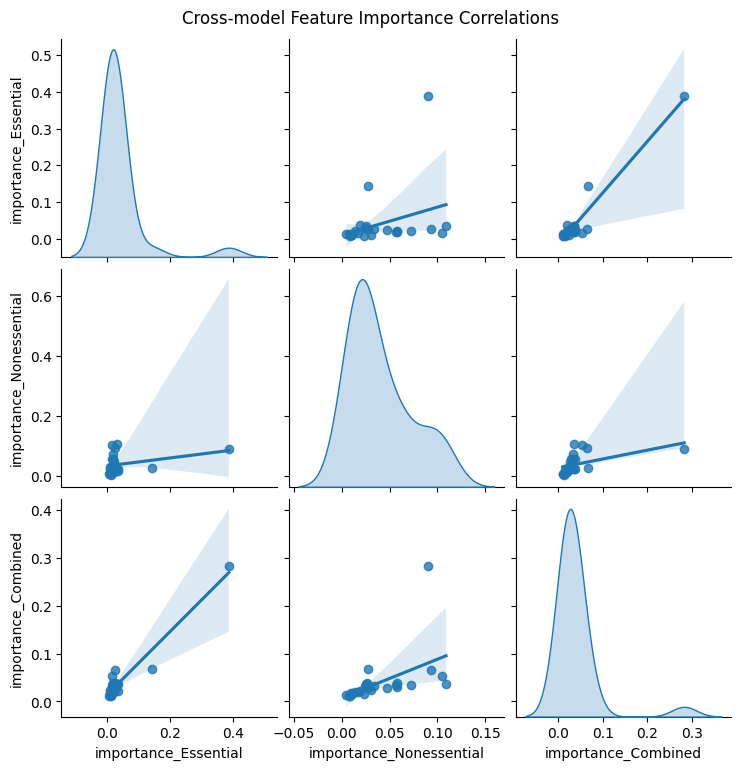

Top-10 overlap (Essential vs Nonessential): 4


In [27]:
def get_feature_importances(model, X, label):
    """
    Compute feature importances for both linear (coef_) and tree-based (feature_importances_) models.

    Returns a DataFrame with columns:
    - feature
    - importance_<label>
    - rank_<label>
    """
    if hasattr(model, "feature_importances_"):   # RandomForest, XGBoost, etc.
        importances = model.feature_importances_

    elif hasattr(model, "coef_"):                # LogisticRegression, Ridge
        importances = np.abs(model.coef_).flatten()

    else:
        raise AttributeError(
            f"Model type {type(model).__name__} has neither coef_ nor feature_importances_."
        )

    df = pd.DataFrame({
        "feature": X.columns,
        f"importance_{label}": importances
    })
    df[f"rank_{label}"] = df[f"importance_{label}"].rank(ascending=False).astype(int)
    df = df.sort_values(by=f"importance_{label}", ascending=False).reset_index(drop=True)

    return df

def derive_feature_groups(feature_names):
    """
    Assign each feature to a biological group based on its prefix or name.
    """
    groups = {}
    for feat in feature_names:
        if feat.startswith("Rosetta_"):
            groups.setdefault("Forcefield_Energy", []).append(feat)
        elif feat.startswith("LLR_dim"):
            groups.setdefault("Expanded_LLR", []).append(feat)
        elif feat.startswith("AAIndex_mut"):
            groups.setdefault("Mutational_AAIndex", []).append(feat)
        elif "Prox" in feat:
            groups.setdefault("Structural_Context", []).append(feat)
        else:
            groups.setdefault("Misc", []).append(feat)
    return groups

model_dict = {
    "Essential": (trained_models["Essential_rf"], X_ess),
    "Nonessential": (trained_models["Nonessential_rf"], X_noness),
    "Combined": (trained_models["Combined_rf"], X_combined)
}

dfs = []
for label, (m, X) in model_dict.items():
    dfs.append(get_feature_importances(m, X, label))

merged_importances = dfs[0]
for df in dfs[1:]:
    merged_importances = merged_importances.merge(df, on="feature", how="outer")
merged_importances = merged_importances.fillna(0)
merged_importances.to_csv("./results/eval_model_feature_importances_merged.csv", index=False)



sns.pairplot(
    merged_importances[[
        "importance_Essential",
        "importance_Nonessential",
        "importance_Combined"
    ]],
    kind="reg", diag_kind="kde"
)
plt.suptitle("Cross-model Feature Importance Correlations", y=1.02)
plt.savefig("./results/cross_model_feature_imp_corr.png", dpi=300)
plt.show()
topk_overlap = len(
    set(merged_importances.sort_values("importance_Essential", ascending=False).head(10)["feature"]) &
    set(merged_importances.sort_values("importance_Nonessential", ascending=False).head(10)["feature"])
)
print(f"Top-10 overlap (Essential vs Nonessential): {topk_overlap}")


,group,importance_Essential,importance_Nonessential,importance_Combined
0,Expanded_LLR,0.2377,0.4965,0.3126
1,Structural_Context,0.3877,0.0903,0.2819
2,Forcefield_Energy,0.2622,0.3079,0.2632
3,Mutational_AAIndex,0.1123,0.1053,0.1422


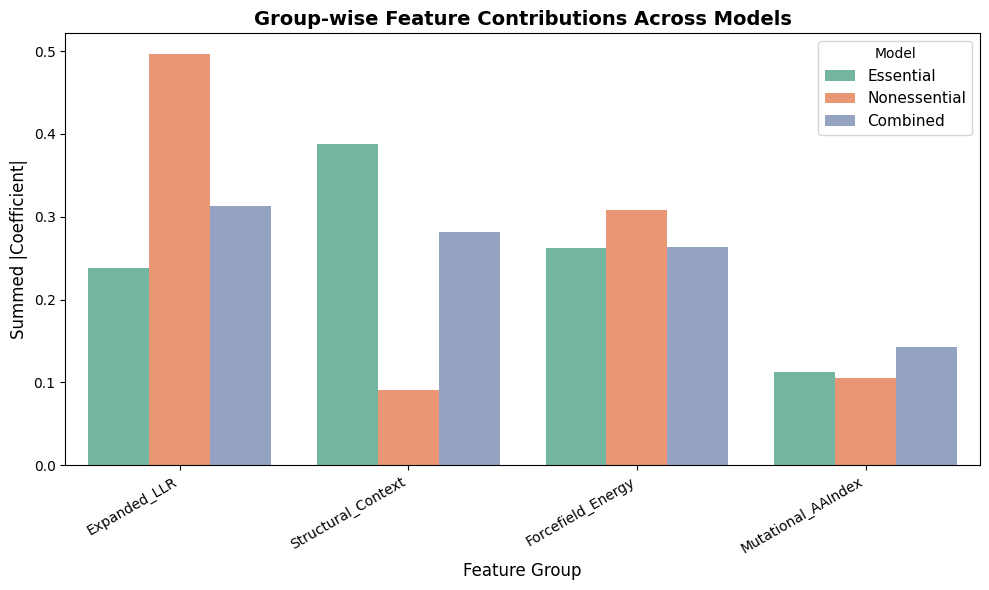

In [28]:
# --- 1. Create feature→group mapping
groups = derive_feature_groups(merged_importances["feature"])
feature_to_group = {f: g for g, feats in groups.items() for f in feats}

# --- 2. Map and group-sum importances
grouped_summary = (
    merged_importances
    .assign(group=merged_importances["feature"].map(feature_to_group))
    .groupby("group")[[
        "importance_Essential",
        "importance_Nonessential",
        "importance_Combined"
    ]]
    .sum()
    .sort_values(by="importance_Combined", ascending=False)
)

grouped_summary = grouped_summary.reset_index()
display(grouped_summary.round(4))



# Melt for grouped barplot
df_plot = grouped_summary.melt(id_vars="group",
                               var_name="Model",
                               value_name="Total_Importance")

# Format model names for nicer plotting
df_plot["Model"] = df_plot["Model"].str.replace("importance_", "")

# --- Plot ---
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_plot,
    x="group", y="Total_Importance", hue="Model",
    palette="Set2"
)
plt.title("Group-wise Feature Contributions Across Models", fontsize=14, weight="bold")
plt.xlabel("Feature Group", fontsize=12)
plt.ylabel("Summed |Coefficient|", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Model", fontsize=11)
plt.tight_layout()

plt.savefig("./results/models_groupwise_feature_contributions.png", dpi=300)
plt.show()


In [29]:
groups

{'Mutational_AAIndex': ['AAIndex_mut1',
  'AAIndex_mut2',
  'AAIndex_mut3',
  'AAIndex_mut4',
  'AAIndex_mut5',
  'AAIndex_mut6',
  'AAIndex_mut7',
  'AAIndex_mut8'],
 'Expanded_LLR': ['LLR_dim124',
  'LLR_dim192',
  'LLR_dim207',
  'LLR_dim258',
  'LLR_dim267',
  'LLR_dim33',
  'LLR_dim39',
  'LLR_dim46',
  'LLR_dim62',
  'LLR_dim70'],
 'Structural_Context': ['Prox_3D_zeroed'],
 'Forcefield_Energy': ['Rosetta_ddG',
  'Rosetta_fa_atr',
  'Rosetta_fa_dun',
  'Rosetta_fa_elec',
  'Rosetta_fa_rep',
  'Rosetta_fa_sol']}

In [30]:
import glob
import pandas as pd

incorrect_files = glob.glob("./results/incorrect_predictions/*_RF_incorrect_predictions.csv")
dfs = []
for f in incorrect_files:
    label = f.split("/")[-1].replace("_RF_incorrect_predictions.csv", "")
    df = pd.read_csv(f)
    df["model_label"] = label
    dfs.append(df)

incorrect_all = pd.concat(dfs, ignore_index=True)
print("Total incorrect samples:", len(incorrect_all))


Total incorrect samples: 16


/tmp/ipykernel_2665714/2006953280.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  incorrect_all = pd.concat(dfs, ignore_index=True)


/tmp/ipykernel_2665714/2609578249.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2665714/2609578249.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2665714/2609578249.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2665714/2609578249.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


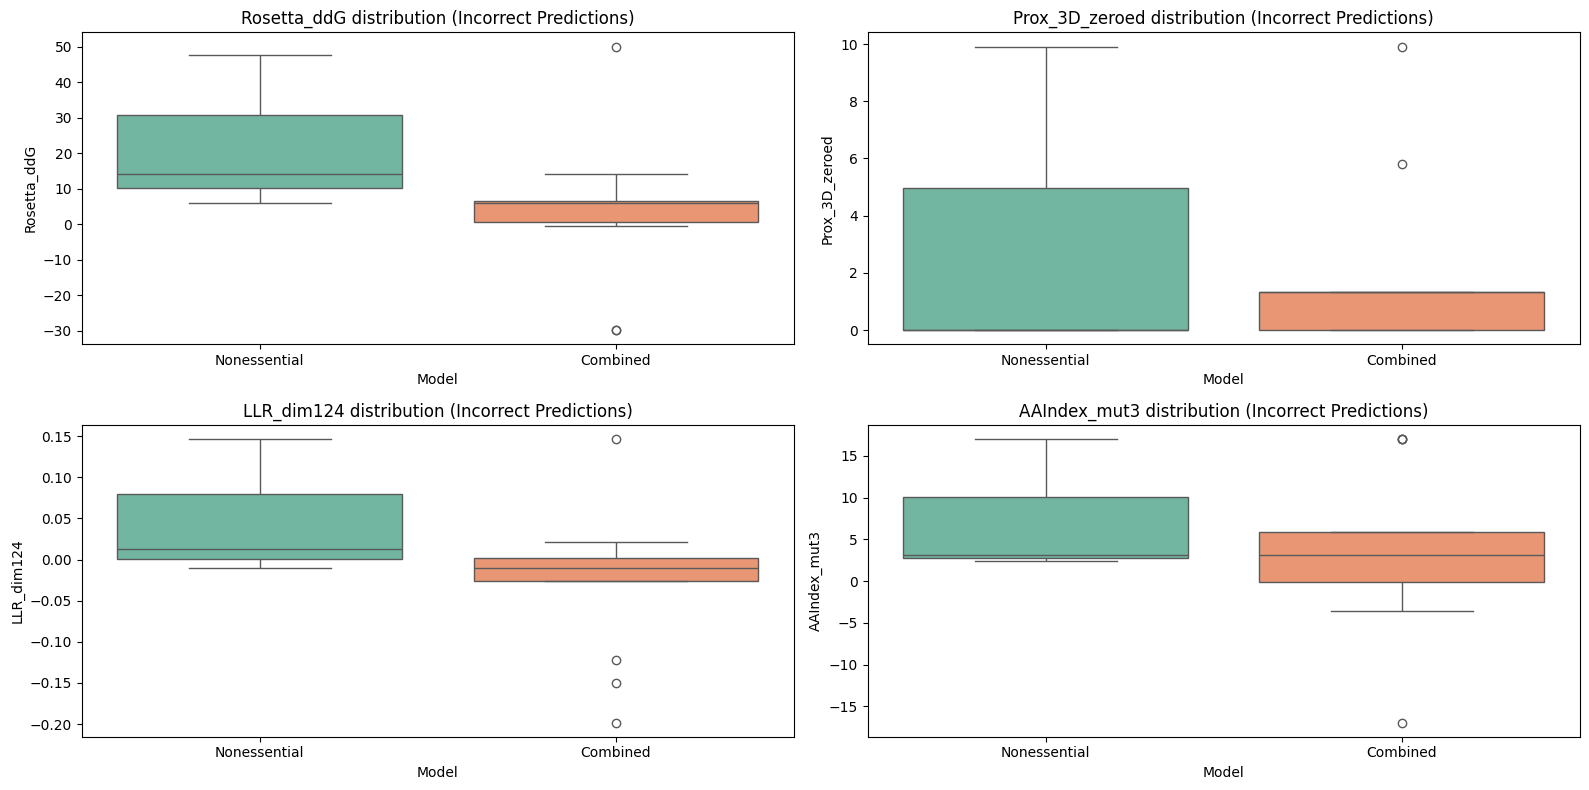

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

features_to_plot = ["Rosetta_ddG", "Prox_3D_zeroed", "LLR_dim124", "AAIndex_mut3"]

plt.figure(figsize=(16, 8))
for i, feat in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        data=incorrect_all,
        x="model_label", y=feat, 
        palette="Set2"
    )
    plt.title(f"{feat} distribution (Incorrect Predictions)")
    plt.xlabel("Model")
    plt.ylabel(feat)
plt.tight_layout()
# plt.savefig("./results/incorrect_feature_distribution_comparison.png", dpi=300)
plt.show()


In [32]:
# Map features → groups
numeric_features = list(X_ess.columns)  
groups = derive_feature_groups(numeric_features)
feature_to_group = {f: g for g, feats in groups.items() for f in feats}

In [33]:
# Group-level feature means for each model - overall signal strength of incorrect samples per biological group
# Define numeric feature columns once


group_summaries = []

for model_name, group in incorrect_all.groupby("model_label"):
    tmp = {"Model": model_name}
    for grp_name, feats in groups.items():
        # Keep only features present in numeric_features
        valid_feats = [f for f in feats if f in numeric_features]
        if valid_feats:
            tmp[grp_name] = group[valid_feats].apply(pd.to_numeric, errors='coerce').abs().mean().mean()
        else:
            tmp[grp_name] = np.nan
    group_summaries.append(tmp)

group_summary_df = pd.DataFrame(group_summaries).melt(
    id_vars="Model",
    var_name="Feature_Group",
    value_name="Mean_Abs_Value"
)

display(group_summary_df)



,Model,Feature_Group,Mean_Abs_Value
0,Combined,Forcefield_Energy,5.382533
1,Nonessential,Forcefield_Energy,7.916125
2,Combined,Structural_Context,1.926894
3,Nonessential,Structural_Context,3.304822
4,Combined,Expanded_LLR,0.080109
5,Nonessential,Expanded_LLR,0.104244
6,Combined,Mutational_AAIndex,5.888756
7,Nonessential,Mutational_AAIndex,6.392820


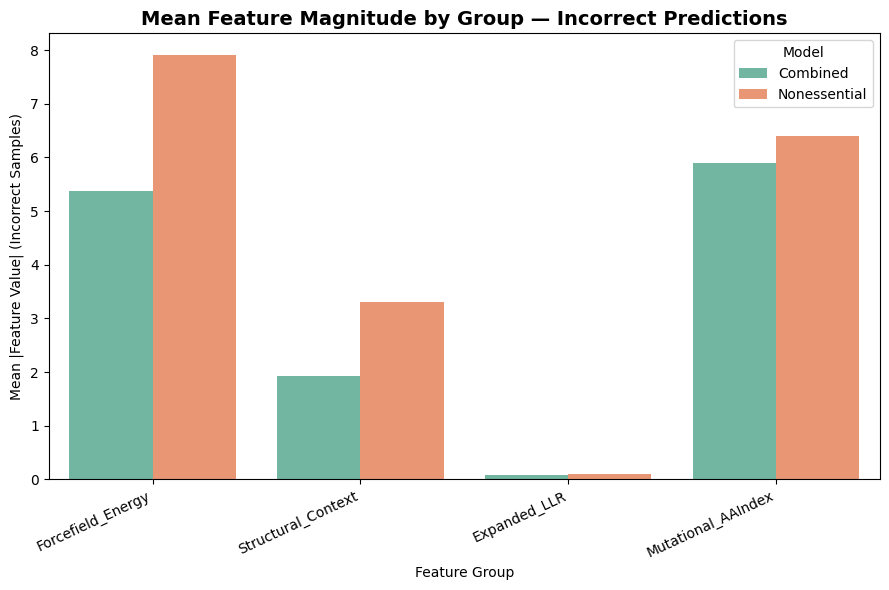

In [34]:
plt.figure(figsize=(9,6))
sns.barplot(
    data=group_summary_df,
    x="Feature_Group", y="Mean_Abs_Value", hue="Model", palette="Set2"
)
plt.title("Mean Feature Magnitude by Group — Incorrect Predictions", fontsize=14, weight="bold")
plt.ylabel("Mean |Feature Value| (Incorrect Samples)")
plt.xlabel("Feature Group")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("./results/groupwise_incorrect_feature_distributions.png", dpi=300)
plt.show()


## wrong predictions per gene

In [35]:
import glob
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# handy aggregates we’ll compute per row
rosetta_cols = [c for c in numeric_features if c.startswith("Rosetta_")]
llr_cols     = [c for c in numeric_features if c.startswith("LLR_dim")]
aa_cols      = [c for c in numeric_features if c.startswith("AAIndex_mut")]
prox_col     = "Prox_3D_zeroed" if "Prox_3D_zeroed" in numeric_features else None


In [36]:
#load incorrects + full predictions for each model label
labels = ["Essential", "Nonessential", "Combined"]  
model_name = "RF" 

# Load incorrects
incorrect_list = []
for lab in labels:
    f = f"./results/incorrect_predictions/{lab}_{model_name}_incorrect_predictions.csv"
    if os.path.exists(f):
        df = pd.read_csv(f)
        df["model_label"] = lab
        incorrect_list.append(df)
incorrect_all = pd.concat(incorrect_list, ignore_index=True) if incorrect_list else pd.DataFrame()
print("Incorrect total:", len(incorrect_all))

# Load full predictions (to compare incorrect vs correct within the same model)
preds_list = []
for lab in labels:
    f = f"./results/{lab}_{model_name}_predictions_on_category3.csv"
    if os.path.exists(f):
        df = pd.read_csv(f)
        df["model_label"] = lab
        preds_list.append(df)
all_preds = pd.concat(preds_list, ignore_index=True) if preds_list else pd.DataFrame()
# print("All preds total:", len(all_preds))

# keep only numeric model features + identifiers
id_cols = [c for c in ["gene", "mutation_oneletter", "confidence_2023", "model_label", "correct"] if c in all_preds.columns]
all_preds = all_preds[id_cols + [c for c in numeric_features if c in all_preds.columns]].copy()
incorrect_all = incorrect_all[[c for c in incorrect_all.columns if c in all_preds.columns]]  # align columns


Incorrect total: 16


/tmp/ipykernel_2665714/3335795782.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  incorrect_all = pd.concat(incorrect_list, ignore_index=True) if incorrect_list else pd.DataFrame()


    model_label  gene  misclassified_count
3      Combined  pncA                    9
0      Combined  ethA                    2
1      Combined   gid                    1
2      Combined  gyrA                    1
5  Nonessential  pncA                    2
4  Nonessential  ethA                    1


/tmp/ipykernel_2665714/1389065131.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x="gene", y="misclassified_count", palette="Reds")


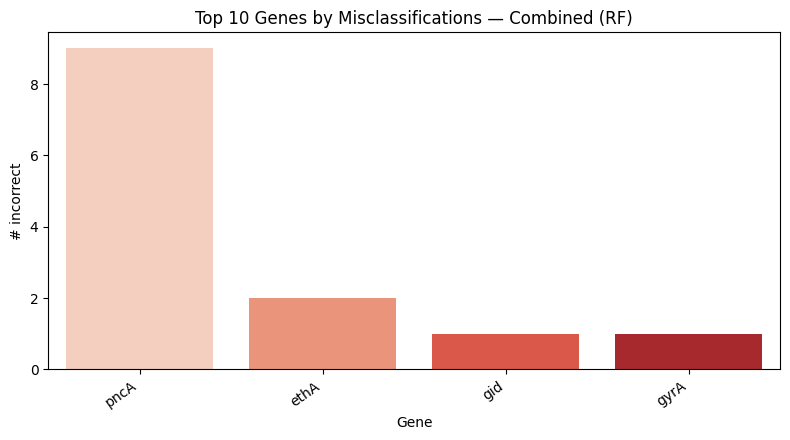

/tmp/ipykernel_2665714/1389065131.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x="gene", y="misclassified_count", palette="Reds")


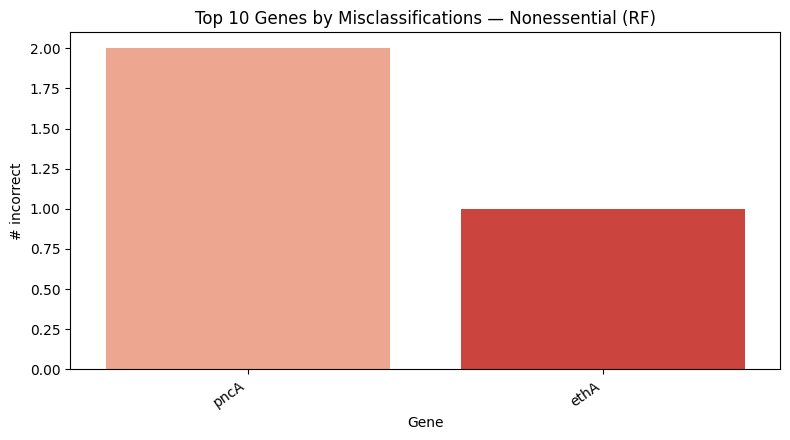

In [37]:
# 2) which genes had the most misclassifications?
# Count per gene & model
mis_by_gene = (incorrect_all
               .groupby(["model_label", "gene"])
               .size()
               .reset_index(name="misclassified_count")
               .sort_values(["model_label", "misclassified_count"], ascending=[True, False]))

print(mis_by_gene.head(20))

# Plot top-N for each model
N = 10
os.makedirs("./results/error_analysis", exist_ok=True)
for lab, sub in mis_by_gene.groupby("model_label"):
    top = sub.head(N)
    plt.figure(figsize=(8, 4.5))
    sns.barplot(data=top, x="gene", y="misclassified_count", palette="Reds")
    plt.title(f"Top {N} Genes by Misclassifications — {lab} ({model_name})")
    plt.xlabel("Gene"); plt.ylabel("# incorrect")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(f"./results/error_analysis/{lab}_{model_name}_top{N}_misclassified_genes.png", dpi=300)
    plt.show()


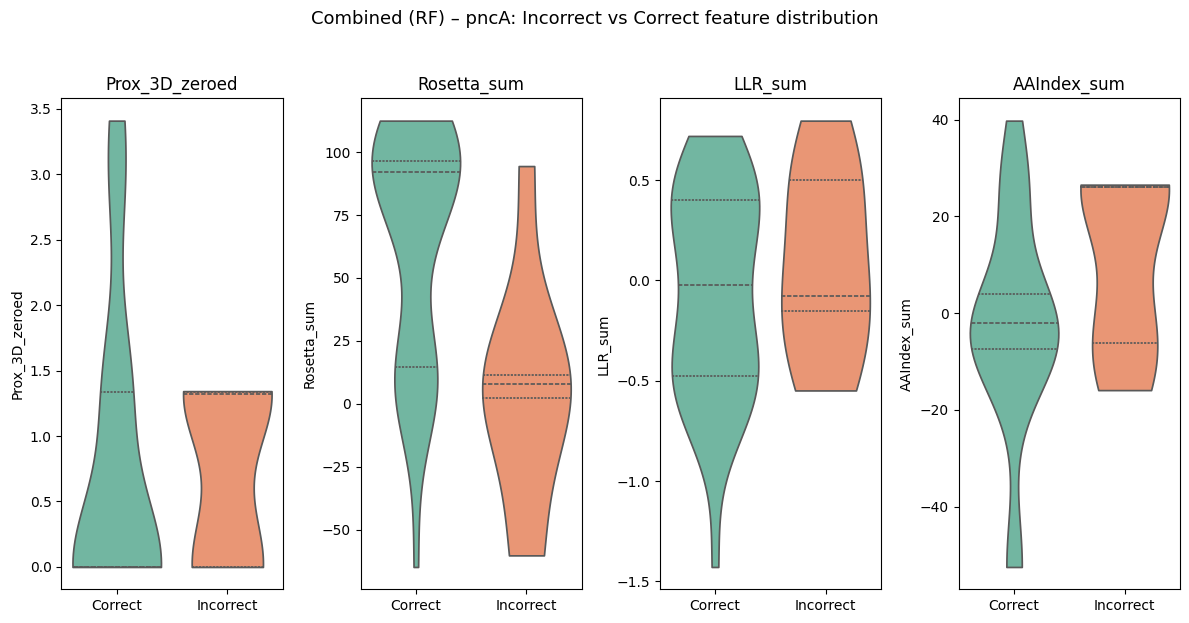

Saved stats → ./results/error_analysis/Combined_RF_pncA_MWU_stats.csv


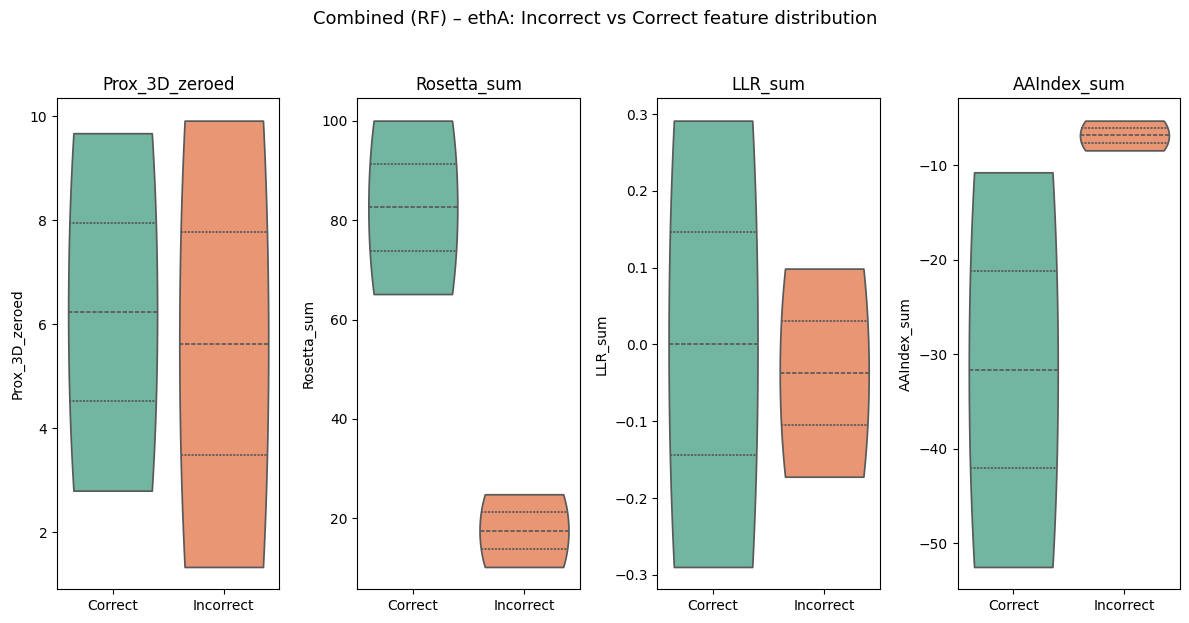

Saved stats → ./results/error_analysis/Combined_RF_ethA_MWU_stats.csv


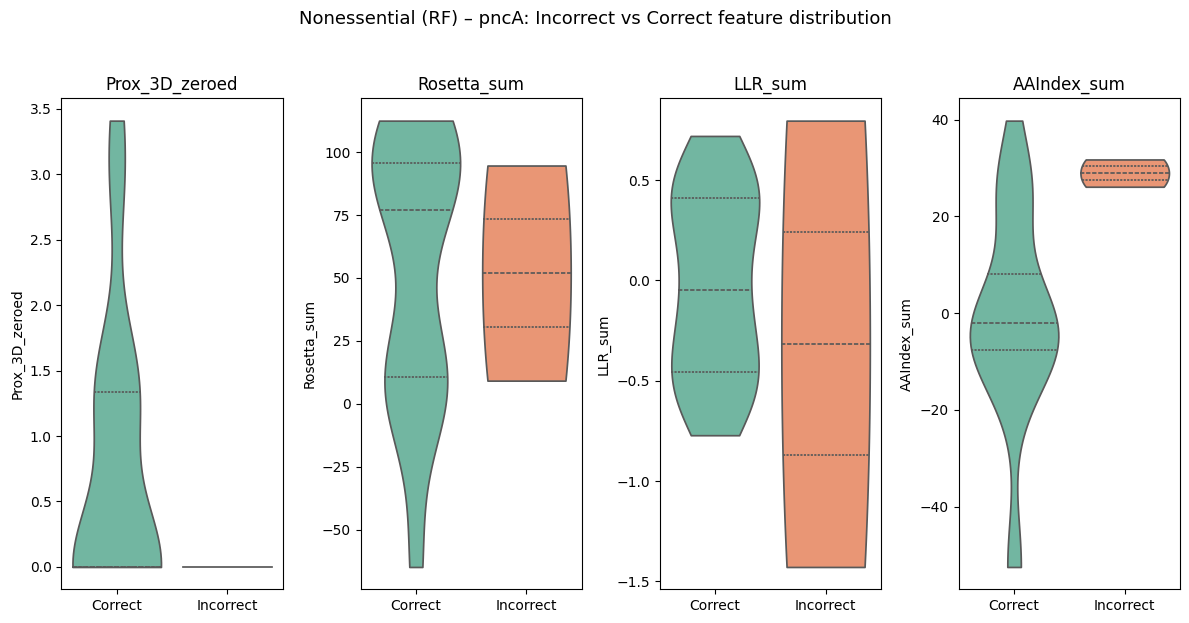

Saved stats → ./results/error_analysis/Nonessential_RF_pncA_MWU_stats.csv


In [ ]:
# compare feature distributions (incorrect vs correct) for top misclassified genes
def add_row_aggregates(df):
    out = df.copy()
    if rosetta_cols: out["Rosetta_sum"] = out[rosetta_cols].sum(axis=1, numeric_only=True)
    if llr_cols:     out["LLR_sum"]     = out[llr_cols].sum(axis=1, numeric_only=True)
    if aa_cols:      out["AAIndex_sum"] = out[aa_cols].sum(axis=1, numeric_only=True)
    return out

all_preds_aug = add_row_aggregates(all_preds)
incorrect_aug = add_row_aggregates(incorrect_all)

features_to_plot = []
if prox_col:          features_to_plot.append(prox_col)
if "Rosetta_sum" in all_preds_aug: features_to_plot.append("Rosetta_sum")
if "LLR_sum" in all_preds_aug:     features_to_plot.append("LLR_sum")
if "AAIndex_sum" in all_preds_aug: features_to_plot.append("AAIndex_sum")

K = 2  # top K genes per model
for lab, sub in mis_by_gene.groupby("model_label"):
    top_genes = sub.head(K)["gene"].tolist()
    base = all_preds_aug[all_preds_aug["model_label"] == lab].copy()
    for g in top_genes:
        base_g = base[base["gene"] == g].copy()
        if "correct" not in base_g.columns:
            continue  # safeguard

        base_g["set"] = np.where(base_g["correct"], "Correct", "Incorrect")

        # violin plot (incorrect vs correct)
        plt.figure(figsize=(12, 6))
        m = len(features_to_plot)
        for i, feat in enumerate(features_to_plot, 1):
            plt.subplot(1, m, i)
            sns.violinplot(data=base_g, x="set", y=feat, inner="quartile", palette="Set2", cut=0,hue="set", legend=False)
            plt.title(feat); plt.xlabel("")
            plt.ylabel(feat)
        plt.suptitle(f"{lab} ({model_name}) – {g}: Incorrect vs Correct feature distribution", y=1.03, fontsize=13)
        plt.tight_layout()
        outp = f"./results/error_analysis/{lab}_{model_name}_{g}_incorrect_vs_correct_violin.png"
        plt.savefig(outp, dpi=300, bbox_inches="tight")
        plt.show()

        # stats: M-W U test incorrect vs correct per feature
        stats_rows = []
        for feat in features_to_plot:
            c = base_g.loc[base_g["set"] == "Correct", feat].dropna()
            ic = base_g.loc[base_g["set"] == "Incorrect", feat].dropna()
            if len(c) > 0 and len(ic) > 0:
                U, p = mannwhitneyu(c, ic, alternative="two-sided")
                stats_rows.append({"gene": g, "model_label": lab, "feature": feat, "U": U, "pval": p, "n_correct": len(c), "n_incorrect": len(ic)})
        if stats_rows:
            stats_df = pd.DataFrame(stats_rows)
            # FDR
            stats_df["pval_adj"] = multipletests(stats_df["pval"], method="fdr_bh")[1]
            stats_out = f"./results/error_analysis/{lab}_{model_name}_{g}_MWU_stats.csv"
            stats_df.to_csv(stats_out, index=False)
            print(f"Saved stats → {stats_out}")


In [ ]:
import pandas as pd
import glob, os
import seaborn as sns
import matplotlib.pyplot as plt

# Path to where the *_MWU_stats.csv files were saved
stats_files = glob.glob("./results/error_analysis/*_MWU_stats.csv")
all_stats = []

for f in stats_files:
    df = pd.read_csv(f)
    df["file"] = os.path.basename(f)
    all_stats.append(df)

if all_stats:
    stats_all = pd.concat(all_stats, ignore_index=True)
else:
    print(" No MWU stats files found.")
    stats_all = pd.DataFrame()

# Flag significance
stats_all["significant"] = stats_all["pval_adj"] < 0.05

# Save combined
stats_all.to_csv("./results/error_analysis/all_MWU_stats_combined.csv", index=False)
display(stats_all.head(10))

# Summary: count significant features per gene
summary = (
    stats_all.groupby(["model_label", "gene"])
    .agg(
        n_tests=("feature", "count"),
        n_sig=("significant", "sum"),
        min_pval=("pval_adj", "min")
    )
    .reset_index()
    .sort_values(["model_label", "n_sig", "min_pval"], ascending=[True, False, True])
)
summary.to_csv("./results/error_analysis/MWU_significance_summary.csv", index=False)
display(summary.head(15))

# Optional: heatmap of p-values
if not stats_all.empty:
    pivot = stats_all.pivot_table(
        index="gene", columns="feature", values="pval_adj", aggfunc="min"
    )
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, cmap="coolwarm_r", cbar_kws={'label': 'Adjusted p-value'}, vmax=1, vmin=0)
    plt.title("Feature-wise Mann–Whitney adjusted p-values (incorrect vs correct)")
    plt.tight_layout()
    plt.savefig("./results/error_analysis/MWU_pval_heatmap.png", dpi=300)
    plt.show()


In [ ]:
feature_sig_summary = (
    stats_all.groupby(["model_label", "feature"])
    .agg(
        n_genes_tested=("gene", "nunique"),
        n_sig=("significant", "sum"),
        frac_sig=("significant", "mean"),
        mean_pval=("pval_adj", "mean")
    )
    .reset_index()
    .sort_values(["model_label", "frac_sig"], ascending=[True, False])
)
display(feature_sig_summary)


In [64]:
# are incorrect calls farther from R variants
# If Prox_3D_zeroed is lower = closer, higher = farther
dist_rows = []
for lab in labels:
    df = all_preds_aug[all_preds_aug["model_label"] == lab]
    if prox_col and prox_col in df.columns:
        tmp = (
            df.groupby(["gene", "correct"])[prox_col]
              .median()
              .unstack("correct")
              .rename(columns={True: "median_prox_correct", False: "median_prox_incorrect"}))
        # Ensure both columns exist (fill missing ones with NaN)
        for col in ["median_prox_correct", "median_prox_incorrect"]:
            if col not in tmp.columns:
                tmp[col] = np.nan

        # Compute delta safely
        tmp["delta_incorrect_minus_correct"] = tmp["median_prox_incorrect"] - tmp["median_prox_correct"]
        tmp["model_label"] = lab
        dist_rows.append(tmp.reset_index())

if dist_rows:
    prox_summary = pd.concat(dist_rows, ignore_index=True)
    prox_summary.to_csv("./results/error_analysis/proximity_incorrect_minus_correct_summary.csv", index=False)
    display(prox_summary.sort_values("delta_incorrect_minus_correct", ascending=False).head(20))


correct,gene,median_prox_correct,median_prox_incorrect,delta_incorrect_minus_correct,model_label
3,ethA,2.803725,9.914465,7.110740,Nonessential
12,pncA,0.000000,1.319170,1.319170,Combined
5,pncA,0.000000,0.000000,0.000000,Nonessential
7,gid,6.194436,5.808522,-0.385914,Combined
6,ethA,6.238540,5.625777,-0.612763,Combined
8,gyrA,43.855673,1.327943,-42.527729,Combined
0,gyrA,25.633919,NaN,NaN,Essential
1,inhA,13.866271,NaN,NaN,Essential
2,katG,0.000000,NaN,NaN,Essential
4,gid,5.808522,NaN,NaN,Nonessential


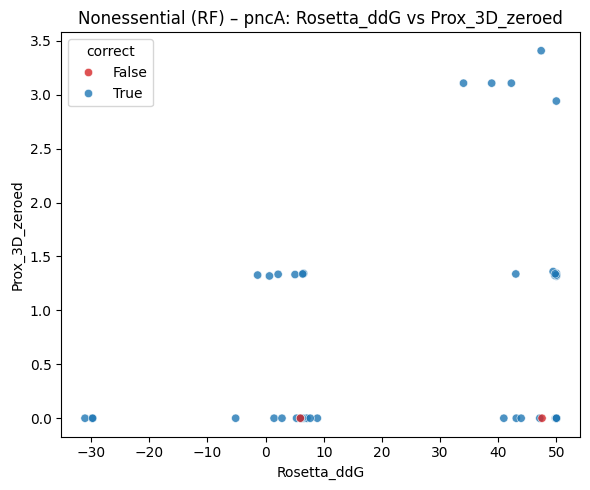

In [65]:
# Example: pick one gene with many errors in nonessential model
target_lab = "Nonessential"
gene_pick = mis_by_gene.query("model_label == @target_lab").iloc[0]["gene"]
dfg = all_preds_aug[(all_preds_aug["model_label"] == target_lab) & (all_preds_aug["gene"] == gene_pick)].copy()

x = "Rosetta_ddG" if "Rosetta_ddG" in dfg.columns else rosetta_cols[0]
y = prox_col if prox_col else "LLR_sum"

plt.figure(figsize=(6,5))
sns.scatterplot(data=dfg, x=x, y=y, hue="correct", palette={True:"tab:blue", False:"tab:red"}, alpha=0.8)
plt.title(f"{target_lab} ({model_name}) – {gene_pick}: {x} vs {y}")
plt.tight_layout()
plt.savefig(f"./results/error_analysis/{target_lab}_{model_name}_{gene_pick}_scatter_{x}_vs_{y}.png", dpi=300)
plt.show()


In [66]:
# which type of biological signals shifts most in misclassified variants

group_delta_summary = []

for lab, sub in all_preds_aug.groupby("model_label"):
    tmp = {"model_label": lab}
    for grp_name, feats in groups.items():
        feats = [f for f in feats if f in sub.columns]
        if not feats:
            continue

        # mean |value| for correct vs incorrect
        correct_vals = sub.loc[sub["correct"], feats].apply(pd.to_numeric, errors="coerce").abs().mean().mean()
        incorrect_vals = sub.loc[~sub["correct"], feats].apply(pd.to_numeric, errors="coerce").abs().mean().mean()

        tmp[f"{grp_name}_correct_mean"] = correct_vals
        tmp[f"{grp_name}_incorrect_mean"] = incorrect_vals
        tmp[f"{grp_name}_delta"] = incorrect_vals - correct_vals  # + = higher in incorrect
    group_delta_summary.append(tmp)

group_delta_df = pd.DataFrame(group_delta_summary)
group_delta_df.to_csv("./results/error_analysis/group_feature_delta_summary.csv", index=False)
display(group_delta_df)


,model_label,Forcefield_Energy_correct_mean,Forcefield_Energy_incorrect_mean,Forcefield_Energy_delta,Structural_Context_correct_mean,Structural_Context_incorrect_mean,Structural_Context_delta,Expanded_LLR_correct_mean,Expanded_LLR_incorrect_mean,Expanded_LLR_delta,Mutational_AAIndex_correct_mean,Mutational_AAIndex_incorrect_mean,Mutational_AAIndex_delta
0,Combined,11.071390,5.382533,-5.688858,4.209035,1.926894,-2.282141,0.091076,0.080109,-0.010968,6.259977,5.888756,-0.371221
1,Essential,2.057970,NaN,NaN,17.150927,NaN,NaN,0.128512,NaN,NaN,5.687283,NaN,NaN
2,Nonessential,11.910093,7.916125,-3.993968,1.478515,3.304822,1.826307,0.084053,0.104244,0.020190,6.483421,6.392820,-0.090600


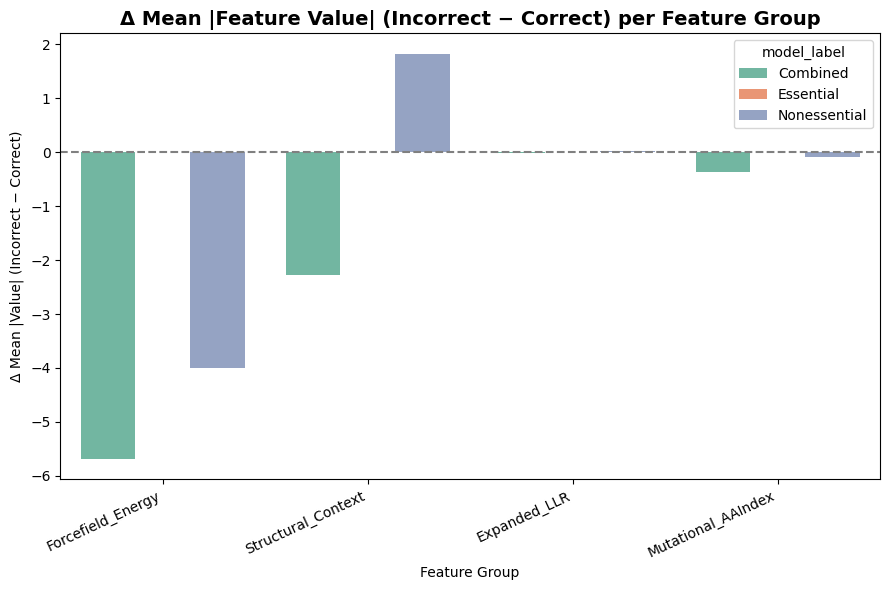

In [67]:
# melt for plotting
melt_cols = [c for c in group_delta_df.columns if c.endswith("_delta")]
plot_df = (
    group_delta_df
    .melt(id_vars="model_label", value_vars=melt_cols,
          var_name="Feature_Group", value_name="Delta_Incorrect_minus_Correct")
)

# clean group names
plot_df["Feature_Group"] = plot_df["Feature_Group"].str.replace("_delta", "", regex=False)

# plot
plt.figure(figsize=(9,6))
sns.barplot(
    data=plot_df,
    x="Feature_Group", y="Delta_Incorrect_minus_Correct",
    hue="model_label", palette="Set2"
)
plt.axhline(0, color="gray", linestyle="--")
plt.title("Δ Mean |Feature Value| (Incorrect − Correct) per Feature Group", fontsize=14, weight="bold")
plt.ylabel("Δ Mean |Value| (Incorrect − Correct)")
plt.xlabel("Feature Group")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("./results/error_analysis/group_feature_deltas_barplot.png", dpi=300)
plt.show()


## shap and further investigations

In [68]:
# compute shap
import shap


def get_shap_importances(model, X, label, class_idx=1):
    """
    Compute mean |SHAP| importance for each feature across all samples.
    Supports both tree-based and linear models (e.g. RandomForest, LogisticRegression).
    Compatible with SHAP ≥0.41.
    """
    # --- Tree-based models ---
    if hasattr(model, "feature_importances_"):
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)

    # --- Linear models (LogisticRegression, etc.) ---
    elif hasattr(model, "coef_"):
        masker = shap.maskers.Independent(X)
        explainer = shap.LinearExplainer(model, masker)
        shap_values = explainer(X)  # returns Explanation object
        shap_values = shap_values.values  # extract array of SHAP values

    else:
        raise ValueError(f"Unsupported model type for SHAP: {type(model).__name__}")

    # --- Handle multiclass output ---
    shap_values = np.array(shap_values)
    if shap_values.ndim == 3:  # shape (n_classes, n_samples, n_features)
        shap_values = shap_values[class_idx]

    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    shap_df = pd.DataFrame({
        "feature": X.columns,
        f"shap_importance_{label}": mean_abs_shap
    })
    shap_df[f"rank_shap_{label}"] = shap_df[f"shap_importance_{label}"].rank(ascending=False).astype(int)
    return shap_df




def merge_coef_shap(model, X, label):
    coef_df = get_feature_importances(model, X, label)  # logistic coefficients
    shap_df = get_shap_importances(model, X, label)
    merged = coef_df.merge(shap_df, on="feature", how="outer")
    return merged.sort_values(f"importance_{label}", ascending=False)

# spearman corr
from scipy.stats import spearmanr

def compute_spearman(df, col1, col2):
    corr, pval = spearmanr(df[col1], df[col2])
    return corr, pval

# top k overlap
def topk_overlap(df1, df2, k=10, col="feature"):
    set1 = set(df1.head(k)[col])
    set2 = set(df2.head(k)[col])
    return len(set1 & set2) / k  # Jaccard overlap ratio
def derive_feature_groups(feature_names):
    """
    Group features into biologically interpretable categories
    based on the 2021/2023 catalog column naming conventions.
    """
    groups = {
        "forcefield_terms": [],
        "biological_context": [],
        "mutational_AAIndex": [],
        "expanded_LLR": [],
        "misc": []
    }

    for feat in feature_names:
        # --- Forcefield / Rosetta energy terms ---
        if feat.startswith("Rosetta_") or feat == "Rosetta_ddG":
            groups["forcefield_terms"].append(feat)

        # --- Proximity and DeltaZ (biological context) ---
        elif any(prefix in feat for prefix in ["Prox_", "DeltaZ"]):
            groups["biological_context"].append(feat)

        # --- AAIndex descriptors ---
        elif feat.startswith("AAIndex_"):
            groups["mutational_AAIndex"].append(feat)

        # --- Expanded LLR features ---
        elif feat.startswith("LLR_dim"):
            groups["expanded_LLR"].append(feat)

        # --- Miscellaneous ---
        else:
            groups["misc"].append(feat)

    # Drop empty groups for neatness
    groups = {k: v for k, v in groups.items() if len(v) > 0}
    return groups
def group_importance_summary(df, value_col, groups):
    results = []
    for gname, feats in groups.items():
        vals = df[df["feature"].isin(feats)][value_col]
        results.append({
            "group": gname,
            "n_features": len(feats),
            "mean_importance": vals.mean(),
            "sum_importance": vals.sum()
        })
    return pd.DataFrame(results).sort_values("mean_importance", ascending=False)
# Step A: Coefficient + SHAP importances
ess_coef_shap = merge_coef_shap(ess_model, X_ess, "Essential")
noness_coef_shap = merge_coef_shap(noness_model, X_noness, "Nonessential")
combined_coef_shap = merge_coef_shap(combined_model, X_combined, "Combined")

# Step B: Compare across models
merged_coef = ess_coef_shap[["feature", "importance_Essential"]].merge(
    noness_coef_shap[["feature", "importance_Nonessential"]], on="feature"
)
merged_shap = ess_coef_shap[["feature", "shap_importance_Essential"]].merge(
    noness_coef_shap[["feature", "shap_importance_Nonessential"]], on="feature"
)

# Spearman correlations
corr_coef, p_coef = compute_spearman(merged_coef, "importance_Essential", "importance_Nonessential")
corr_shap, p_shap = compute_spearman(merged_shap, "shap_importance_Essential", "shap_importance_Nonessential")

print(f"Spearman (coeff importances): {corr_coef:.3f}  p={p_coef:.3g}")
print(f"Spearman (SHAP importances):  {corr_shap:.3f}  p={p_shap:.3g}")

# Top-10 overlap
overlap_coef = topk_overlap(ess_coef_shap, noness_coef_shap, k=10)
overlap_shap = topk_overlap(
    ess_coef_shap.sort_values("shap_importance_Essential", ascending=False),
    noness_coef_shap.sort_values("shap_importance_Nonessential", ascending=False),
    k=10
)
print("Top-10 overlap (coeff):", overlap_coef)
print("Top-10 overlap (SHAP):", overlap_shap)

# step c group level summaries
groups = derive_feature_groups(X_ess.columns)

ess_group_coef  = group_importance_summary(ess_coef_shap,  "importance_Essential", groups)
ess_group_shap  = group_importance_summary(ess_coef_shap,  "shap_importance_Essential", groups)
noness_group_coef = group_importance_summary(noness_coef_shap, "importance_Nonessential", groups)
noness_group_shap = group_importance_summary(noness_coef_shap, "shap_importance_Nonessential", groups)

print("Essential (coeff) groups:\n", ess_group_coef)
print("Essential (SHAP) groups:\n", ess_group_shap)
print("Nonessential (coeff) groups:\n", noness_group_coef)
print("Nonessential (SHAP) groups:\n", noness_group_shap)



NameError: name 'ess_model' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_importance_side_by_side(merged_coef, merged_shap,
                                 topk=10,
                                 save_dir="./results",
                                 filename="Essential_vs_Nonessential_Importances.png"):
    """
    Create side-by-side scatter plots comparing Essential vs Nonessential
    feature importances for both Coefficients and SHAP values.
    """

    os.makedirs(save_dir, exist_ok=True)

    def _plot(ax, df, col_x, col_y, label_x, label_y, title, topk):
        df = df.copy()
        df["rank_x"] = df[col_x].rank(ascending=False)
        df["rank_y"] = df[col_y].rank(ascending=False)

        # Base scatter
        sns.scatterplot(data=df, x=col_x, y=col_y, color="gray", alpha=0.6, s=35, ax=ax)

        # Top-k
        top_x = df.nsmallest(topk, "rank_x")
        top_y = df.nsmallest(topk, "rank_y")

        ax.scatter(top_x[col_x], top_x[col_y], color="#1f77b4", s=50, label=f"Top-{topk} Essential")
        ax.scatter(top_y[col_x], top_y[col_y], color="#d62728", s=50, marker="x", label=f"Top-{topk} Nonessential")

        # Overlap annotation
        overlap = set(top_x["feature"]) & set(top_y["feature"])
        for _, row in df[df["feature"].isin(overlap)].iterrows():
            ax.text(row[col_x], row[col_y], row["feature"], fontsize=8,
                    ha="right", va="bottom", color="black")

        # Diagonal line
        lims = [
            min(df[[col_x, col_y]].min()) * 0.9,
            max(df[[col_x, col_y]].max()) * 1.1
        ]
        ax.plot(lims, lims, "--", color="gray", lw=1)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xlabel(label_x, fontsize=12, weight="bold")
        ax.set_ylabel(label_y, fontsize=12, weight="bold")
        ax.set_title(title, fontsize=13, weight="bold")
        ax.grid(alpha=0.3)
        ax.legend(frameon=False, fontsize=9)

    # --- Two subplots side-by-side ---
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    _plot(
        axes[0],
        merged_coef,
        "importance_Essential",
        "importance_Nonessential",
        "Coefficient (Essential)",
        "Coefficient (Nonessential)",
        "Coefficient Importances",
        topk,
    )

    _plot(
        axes[1],
        merged_shap,
        "shap_importance_Essential",
        "shap_importance_Nonessential",
        "SHAP (Essential)",
        "SHAP (Nonessential)",
        "SHAP Importances",
        topk,
    )

    plt.suptitle("Essential vs Nonessential Feature Importance Comparison", fontsize=15, weight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[Saved] {save_path}")


In [ ]:
plot_importance_side_by_side(
    merged_coef,
    merged_shap,
    topk=10,
    filename="Essential_vs_Nonessential_Importances_side_by_side.png"
)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_rank_slope(df, rank_col1, rank_col2, label1="Essential", label2="Nonessential", topk=10):
    """
    Draw a slope plot comparing feature ranks across two models.
    
    df : DataFrame with columns ['feature', rank_col1, rank_col2]
    rank_col1, rank_col2 : columns with ranks (lower = more important)
    label1, label2 : labels for the two axes
    topk : restrict to features that appear in top-k of either model
    """
    df = df.copy()
    # Keep only features that are in top-k of either list
    df = df[(df[rank_col1] <= topk) | (df[rank_col2] <= topk)]

    plt.figure(figsize=(7, 0.4 * len(df)))
    for _, row in df.iterrows():
        plt.plot([1, 2], [row[rank_col1], row[rank_col2]],
                 marker="o",
                 color="blue" if (row[rank_col1] <= topk and row[rank_col2] <= topk) else "red")
        plt.text(0.95, row[rank_col1], row["feature"], ha="right", va="center", fontsize=8)

    plt.xticks([1, 2], [label1, label2])
    plt.gca().invert_yaxis()
    plt.ylabel("Rank (1 = top)")
    plt.title(f"Feature Rank Comparison: {label1} vs {label2} (Top-{topk})")
    plt.tight_layout()
    plt.show()


In [ ]:
# Add ranks
merged_coef["rank_Essential"] = merged_coef["importance_Essential"].rank(ascending=False).astype(int)
merged_coef["rank_Nonessential"] = merged_coef["importance_Nonessential"].rank(ascending=False).astype(int)

merged_shap["rank_Essential"] = merged_shap["shap_importance_Essential"].rank(ascending=False).astype(int)
merged_shap["rank_Nonessential"] = merged_shap["shap_importance_Nonessential"].rank(ascending=False).astype(int)

# Plot (use merged_coef instead of merged_rf)
plot_rank_slope(
    merged_coef,
    "rank_Essential",
    "rank_Nonessential",
    label1="Essential (Coefficients)",
    label2="Nonessential (Coefficients)",
    topk=10
)

plot_rank_slope(
    merged_shap,
    "rank_Essential",
    "rank_Nonessential",
    label1="Essential (SHAP)",
    label2="Nonessential (SHAP)",
    topk=10
)



In [ ]:
def groups_summary_dataframe(groups):
    data = [{"group": g, "n_features": len(feats), "features": feats}
            for g, feats in groups.items()]
    return pd.DataFrame(data)

# Example
groups_summary = groups_summary_dataframe(groups)
groups_summary


## evaluation on uncertain confidence

In [ ]:
# Side-by-side agreement ONLY on uncertain rows
ct = pd.crosstab(
    cat3["pred_conf_ess"],
    cat3["pred_conf_noness"],
    rownames=["Essential"],
    colnames=["Nonessential"]
)
print(ct)

agreement = (cat3["pred_conf_ess"] == cat3["pred_conf_noness"]).mean()
print(f"Agreement on uncertain entries: {agreement:.2%}")

# NaN checks (should be zero now because cat3 contains only uncertain rows that were predicted)
print(cat3[["pred_conf_ess","pred_conf_noness"]].isna().sum())


In [ ]:
print(cat3[["pred_conf_ess", "pred_conf_noness"]].isna().sum())
nan_rows = cat3[["pred_conf_ess", "pred_conf_noness"]].isna().any(axis=1)
print(f"Rows with NaN in predictions: {nan_rows.sum()}")
print("Indices with NaN predictions:", cat3[nan_rows].index.tolist())

# # Verify features for one of them
# idx = cat3[nan_rows].index[0]
# print(cat3.loc[idx, X_ess.columns])



### visualize feature distribution

In [ ]:
#histograms and KDE
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the datasets with an indicator
label_data['dataset'] = 'Training Data'
category_3_data['dataset'] = 'Prediction Set'

combined_data = pd.concat([label_data, category_3_data], ignore_index=True)

# Plot histograms and KDE plots for each numeric feature
for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=combined_data, x=col, hue='dataset', kde=True, stat="density", common_norm=False)
    plt.title(f'Distribution of {col}')
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='final_label', y=col, hue='dataset', data=combined_data)
    plt.title(f'Box Plot of {col} by Final Label and Dataset')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.violinplot(x='final_label', y=col, hue='dataset', data=combined_data, split=True)
    plt.title(f'Violin Plot of {col} by Final Label and Dataset')
    plt.show()


In [ ]:
## pair plots
sns.pairplot(combined_data, vars=numeric_columns, hue='dataset', diag_kind='kde')
plt.show()

### stat significance test: check if diff in dist significant

In [ ]:
# Kolmogorov-Smirnov Test:This test compares the distributions of two samples.
from scipy.stats import ks_2samp

for col in numeric_columns:
    stat, p_value = ks_2samp(label_data[col], category_3_data[col])
    print(f'Kolmogorov-Smirnov test for {col}: statistic={stat}, p-value={p_value}')


In [ ]:
# Mann-Whitney U Test
# A non-parametric test to compare medians of two independent samples.
from scipy.stats import mannwhitneyu

for col in numeric_columns:
    stat, p_value = mannwhitneyu(label_data[col], category_3_data[col], alternative='two-sided')
    print(f'Mann-Whitney U test for {col}: statistic={stat}, p-value={p_value}')

In [ ]:
from scipy.stats import ttest_ind

for col in numeric_columns:
    stat, p_value = ttest_ind(label_data[col], category_3_data[col], equal_var=False)
    print(f'T-Test for {col}: statistic={stat}, p-value={p_value}')


In [ ]:
label_stats = label_data[numeric_columns].describe().transpose()
category_3_stats = category_3_data[numeric_columns].describe().transpose()

# Combine the statistics
summary_stats = label_stats.join(category_3_stats, lsuffix='_label', rsuffix='_category_3')

display(summary_stats)


### feature importance

In [ ]:

importances = rf_classifier.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': numeric_columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df)


### dimensionality Reduction

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Combine the data
combined_features = combined_data[numeric_columns]
combined_features = combined_features.fillna(0)  # Ensure no NaNs

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(combined_features)

# Apply PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

# Create a DataFrame with principal components
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['dataset'] = combined_data['dataset'].values

# Plot the PCA results
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='dataset', data=pca_df)
plt.title('PCA of Feature Set')
plt.show()


### overlapping histograms

In [ ]:
for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    plt.hist(label_data[col], bins=30, alpha=0.5, label='Training Data', density=True)
    plt.hist(category_3_data[col], bins=30, alpha=0.5, label='Prediction Set', density=True)
    plt.title(f'Overlapping Histogram of {col}')
    plt.legend()
    plt.show()


### qq plots

In [ ]:
import statsmodels.api as sm

for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    sm.qqplot(label_data[col], line='s', label='Training Data')
    sm.qqplot(category_3_data[col], line='s', label='Prediction Set')
    plt.title(f'QQ Plot of {col}')
    plt.legend()
    plt.show()
    break

### corr analysis

In [ ]:
# Compute correlation matrices
corr_label = label_data[numeric_columns].corr()
corr_category_3 = category_3_data[numeric_columns].corr()

# Plot correlation heatmaps
plt.figure(figsize=(8, 6))
sns.heatmap(corr_label, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix - Training Data')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_category_3, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix - Prediction Set')
plt.show()


In [ ]:
label_data.columns

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Identify Relevant Columns
expanded_llr_features = [col for col in label_data.columns if col.startswith("expanded_llr_dim_")]
bio_properties = ["thermostability","Proximity_to_R_Conferring",'mut_AAIndex1', 'mut_AAIndex2',
       'mut_AAIndex3']  # Add more if needed

# Step 2: Compute Correlation Matrices (Expanded LLR vs. Bio Properties)
corr_label_llr_bio = label_data[expanded_llr_features + bio_properties].corr()
corr_category_3_llr_bio = category_3_data[expanded_llr_features + bio_properties].corr()

# Step 3: Extract Only the Rows for LLR Features and Columns for Bio Properties
corr_label_selected = corr_label_llr_bio.loc[expanded_llr_features, bio_properties]
corr_category_3_selected = corr_category_3_llr_bio.loc[expanded_llr_features, bio_properties]

# Step 4: Plot Heatmaps
plt.figure(figsize=(10, 6))
sns.heatmap(corr_label_selected, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation: Expanded LLR Features vs. Bio Properties (Training Data)')
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_category_3_selected, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation: Expanded LLR Features vs. Bio Properties (Prediction Set)')
plt.show()


In [ ]:
corr_label_selected

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=label_data["expanded_llr_dim_553"], y=label_data["mut_AAIndex3"])
plt.title("Scatter Plot: Expanded LLR 553 vs. Mutation AAIndex3")
plt.show()


### examine outliers

In [ ]:
for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='dataset', y=col, hue='final_label', data=combined_data)
    plt.title(f'Outliers in {col} by Dataset and Label')
    plt.show()


In [ ]:
# for col in numeric_columns:
#     plt.figure(figsize=(10, 6))
#     sns.boxplot(x='dataset', y=col, data=combined_data)
#     plt.title(f'Outliers in {col}')
#     plt.show()


### analyze the impact on model performance

In [ ]:
#Partial Dependence Plots: Show the relationship between the target variable and a feature.
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

for feature in numeric_columns:
    disp = PartialDependenceDisplay.from_estimator(rf_classifier, X_category_3, [feature])
    plt.show()


In [ ]:
### use shap values

In [ ]:
import shap

# Initialize the JS visualization code
shap.initjs()

# Explain predictions using SHAP
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_category_3)

# Visualize the first prediction's explanation
shap.force_plot(explainer.expected_value[1], shap_values[1][0,:], X_category_3.iloc[0,:])
